### 1.1 V1.0 生成不同分布类型的函数
为post.csv文件生成一个oracle分布（偏斜正态分布，往低概率偏斜），列名为ML3_oracle_probility, 然后生成与ML3_oracle_probility 分布近似（考虑添加噪声、上下左右平移或者更复杂的处理方法）的 ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility，同时要求以ML3_oracle_probility>0.5为ground_truth,ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility 的F1 分数分别大于0.9,0.75,0.6

成功读取 /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv，共 24082 行数据。
开始生成多种分布...

[Dist_SkewLow] Positive Rate: 3.35%
[Dist_SkewHigh] Positive Rate: 94.73%
[Dist_Normal] Positive Rate: 38.12%
[Dist_Bimodal] Positive Rate: 54.25%
[Dist_Uniform] Positive Rate: 50.34%
[Dist_Beta_U] Positive Rate: 49.34%


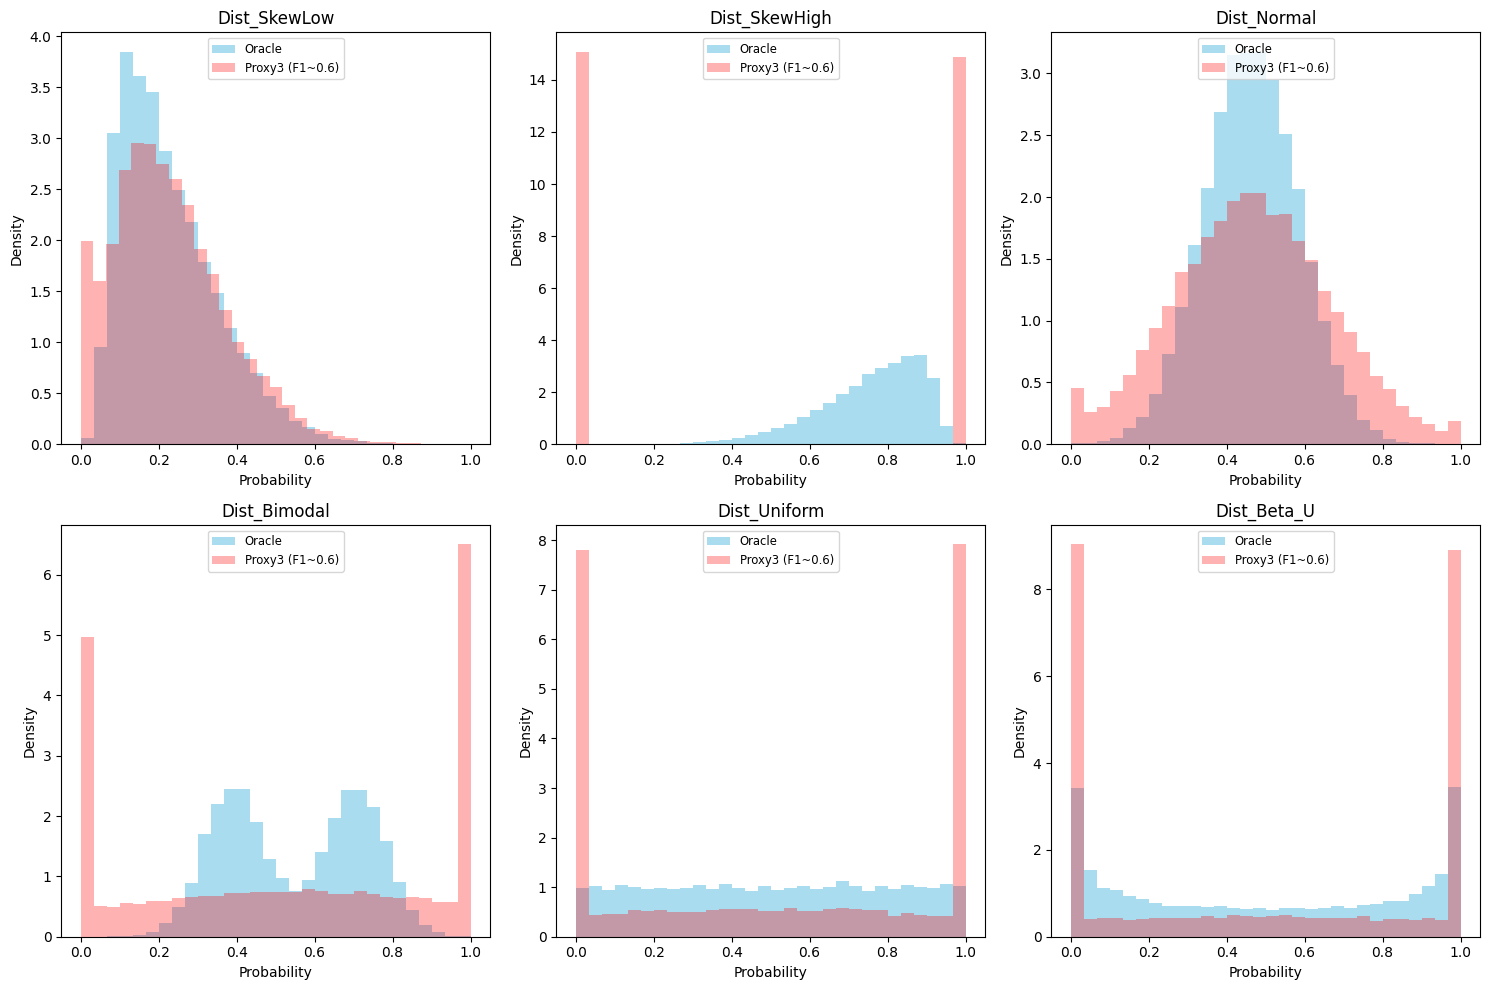


F1 Scores for Oracle and Proxies:
Dist_SkewLow_oracle_prob: Proxy1 F1=0.8852, Proxy2 F1=0.7974, Proxy3 F1=0.6280
Dist_SkewHigh_oracle_prob: Proxy1 F1=0.8996, Proxy2 F1=0.7921, Proxy3 F1=0.6498
Dist_Normal_oracle_prob: Proxy1 F1=0.8869, Proxy2 F1=0.7877, Proxy3 F1=0.6452
Dist_Bimodal_oracle_prob: Proxy1 F1=0.8959, Proxy2 F1=0.7998, Proxy3 F1=0.6465
Dist_Uniform_oracle_prob: Proxy1 F1=0.8995, Proxy2 F1=0.7855, Proxy3 F1=0.6428
Dist_Beta_U_oracle_prob: Proxy1 F1=0.8922, Proxy2 F1=0.7828, Proxy3 F1=0.6433

文件已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post_with_multi_distributions.csv


In [2]:
# 在 notebook 顶部添加（如果已添加则无需重复）
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from sklearn.metrics import f1_score

class DistributionGenerator:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = self._load_data()
        self.N = len(self.df)
        self.plot_cols = []

    def _load_data(self):
        """加载数据文件，如果不存在则生成示例数据"""
        try:
            df = pd.read_csv(self.file_path)
            print(f"成功读取 {self.file_path}，共 {len(df)} 行数据。")
        except FileNotFoundError:
            print("未找到文件，生成示例数据...")
            df = pd.DataFrame({'id': range(2000)})
        return df

    @staticmethod
    def normalize(data):
        """将任意分布归一化到 [0, 1]"""
        return (data - data.min()) / (data.max() - data.min())

    def generate_proxy_with_target_f1(self, oracle_probs, gt, target_f1_min, target_f1_max):
        """
        通过向 Oracle 添加噪声来生成 Proxy，直到 F1 分数落在目标区间内。
        """
        sigma = 0.01 
        
        # 如果 GT 全是 0 或 全是 1，F1 可能无法计算或恒定，做个简单保护
        if len(np.unique(gt)) < 2:
            print("Warning: Ground Truth has only one class. Returning original probs.")
            return oracle_probs

        for i in range(200):
            noise = np.random.normal(0, sigma, size=len(oracle_probs))
            proxy_probs = np.clip(oracle_probs + noise, 0, 1)
            
            proxy_pred = (proxy_probs > 0.5).astype(int)
            current_f1 = f1_score(gt, proxy_pred, zero_division=0)
            
            if target_f1_min <= current_f1 <= target_f1_max:
                return proxy_probs
            
            if current_f1 > target_f1_max:
                sigma *= 1.1 # F1太高，增加噪声
            elif current_f1 < target_f1_min:
                sigma *= 0.9 # F1太低，减少噪声
                
        return proxy_probs

    def process_distribution(self, name_prefix, raw_data):
        """
        处理单个分布的完整流程：归一化 -> 生成GT -> 生成3个Proxy -> 保存到df
        """
        # 1. 归一化得到 Oracle Probability
        oracle_prob = self.normalize(raw_data)
        col_oracle = f'{name_prefix}_oracle_prob'
        self.df[col_oracle] = oracle_prob
        
        # 2. 生成 Ground Truth
        gt = (oracle_prob > 0.5).astype(int)
        pos_rate = gt.mean()
        print(f"[{name_prefix}] Positive Rate: {pos_rate:.2%}")
        
        # 3. 生成 Proxies
        # Proxy 1: F1 > 0.85
        self.df[f'{name_prefix}_proxy1'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.85, 0.90)
        # Proxy 2: F1 > 0.75
        self.df[f'{name_prefix}_proxy2'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.75, 0.80)
        # Proxy 3: F1 > 0.6
        self.df[f'{name_prefix}_proxy3'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.60, 0.65)
        
        self.plot_cols.append(col_oracle)

    def generate_distributions(self):
        """生成多种分布"""
        print("开始生成多种分布...\n")

        # --- A. Skewed Low (右偏，低概率为主) ---
        raw_skew_low = skewnorm.rvs(a=10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewLow', raw_skew_low)

        # --- B. Skewed High (左偏，高概率为主) ---
        raw_skew_high = skewnorm.rvs(a=-10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewHigh', raw_skew_high)

        # --- C. Normal / Gaussian (正态分布，居中) ---
        raw_normal = np.random.normal(loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_Normal', raw_normal)

        # --- D. Bimodal (双峰分布，两极分化) ---
        dist1 = np.random.normal(-2, 1, int(self.N/2))
        dist2 = np.random.normal(2, 1, self.N - int(self.N/2))
        raw_bimodal = np.concatenate([dist1, dist2])
        np.random.shuffle(raw_bimodal)
        self.process_distribution('Dist_Bimodal', raw_bimodal)

        # --- E. Uniform (均匀分布) ---
        raw_uniform = np.random.uniform(0, 1, self.N)
        self.process_distribution('Dist_Uniform', raw_uniform)

        # --- F. Beta Distribution (U型分布，更极端的两极分化) ---
        raw_beta = np.random.beta(0.5, 0.5, size=self.N)
        self.process_distribution('Dist_Beta_U', raw_beta)

    def calculate_f1_scores(self):
        """计算每个 Oracle 对应的三个 Proxy 的 F1 分数"""
        print("\nF1 Scores for Oracle and Proxies:")
        for col_name in self.plot_cols:
            gt = (self.df[col_name] > 0.5).astype(int)
            proxy1_col = col_name.replace('oracle_prob', 'proxy1')
            proxy2_col = col_name.replace('oracle_prob', 'proxy2')
            proxy3_col = col_name.replace('oracle_prob', 'proxy3')
            
            f1_proxy1 = f1_score(gt, (self.df[proxy1_col] > 0.5).astype(int))
            f1_proxy2 = f1_score(gt, (self.df[proxy2_col] > 0.5).astype(int))
            f1_proxy3 = f1_score(gt, (self.df[proxy3_col] > 0.5).astype(int))
            
            print(f"{col_name}: Proxy1 F1={f1_proxy1:.4f}, Proxy2 F1={f1_proxy2:.4f}, Proxy3 F1={f1_proxy3:.4f}")

    def visualize_distributions(self):
        """可视化所有分布"""
        plt.figure(figsize=(15, 10))

        for i, col_name in enumerate(self.plot_cols):
            plt.subplot(2, 3, i+1)
            # 画 Oracle
            plt.hist(self.df[col_name], bins=30, color='skyblue', alpha=0.7, label='Oracle', density=True)
            # 画对应的最差 Proxy (Proxy3) 对比
            proxy3_name = col_name.replace('oracle_prob', 'proxy3')
            plt.hist(self.df[proxy3_name], bins=30, color='red', alpha=0.3, label='Proxy3 (F1~0.6)', density=True)
            
            plt.title(col_name.replace('_oracle_prob', ''))
            plt.xlabel('Probability')
            plt.ylabel('Density')
            plt.legend(loc='upper center', fontsize='small')

        plt.tight_layout()
        plt.show()

    def save_distributions(self):
        """保存生成的分布到文件"""
        save_path = self.file_path.replace('post.csv', 'post_with_multi_distributions.csv')
        self.df.to_csv(save_path, index=False)
        print(f"\n文件已保存至: {save_path}")

# 使用类
file_path = '/home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv'
generator = DistributionGenerator(file_path)
generator.generate_distributions()
generator.visualize_distributions()
generator.calculate_f1_scores()  # 输出 F1 分数
generator.save_distributions()

### 1. V2.0 生成不同分布类型的函数
为post.csv文件生成一个oracle分布（偏斜正态分布，往低概率偏斜），列名为ML3_oracle_probility, 然后生成与ML3_oracle_probility 分布近似（考虑添加噪声、上下左右平移或者更复杂的处理方法）的 ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility，同时要求以ML3_oracle_probility>0.5为ground_truth,ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility 的F1 分数分别大于0.9,0.75,0.6

成功读取 /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv，共 24082 行数据。
开始生成多种分布...

[Dist_SkewLow] Positive Rate: 5.81%
[Dist_SkewHigh] Positive Rate: 94.15%
[Dist_Normal] Positive Rate: 61.14%
[Dist_Bimodal] Positive Rate: 49.20%
[Dist_Uniform] Positive Rate: 50.21%
[Dist_Beta_U] Positive Rate: 49.29%

--- Similarity metrics for Dist_SkewLow_oracle_prob ---
Proxy1: KS_stat=0.0181, KS_p=0.0007106, Wasserstein=0.002523
Proxy2: KS_stat=0.0425, KS_p=2.561e-19, Wasserstein=0.007950

--- Similarity metrics for Dist_SkewHigh_oracle_prob ---
Proxy1: KS_stat=0.2559, KS_p=0, Wasserstein=0.102965
Proxy2: KS_stat=0.3666, KS_p=0, Wasserstein=0.206709

--- Similarity metrics for Dist_Normal_oracle_prob ---
Proxy1: KS_stat=0.0233, KS_p=4.15e-06, Wasserstein=0.009318
Proxy2: KS_stat=0.0887, KS_p=7.118e-83, Wasserstein=0.043950

--- Similarity metrics for Dist_Bimodal_oracle_prob ---
Proxy1: KS_stat=0.0573, KS_p=7.348e-35, Wasserstein=0.029045
Proxy2: KS_stat=0.1088, KS_p=1.139e-

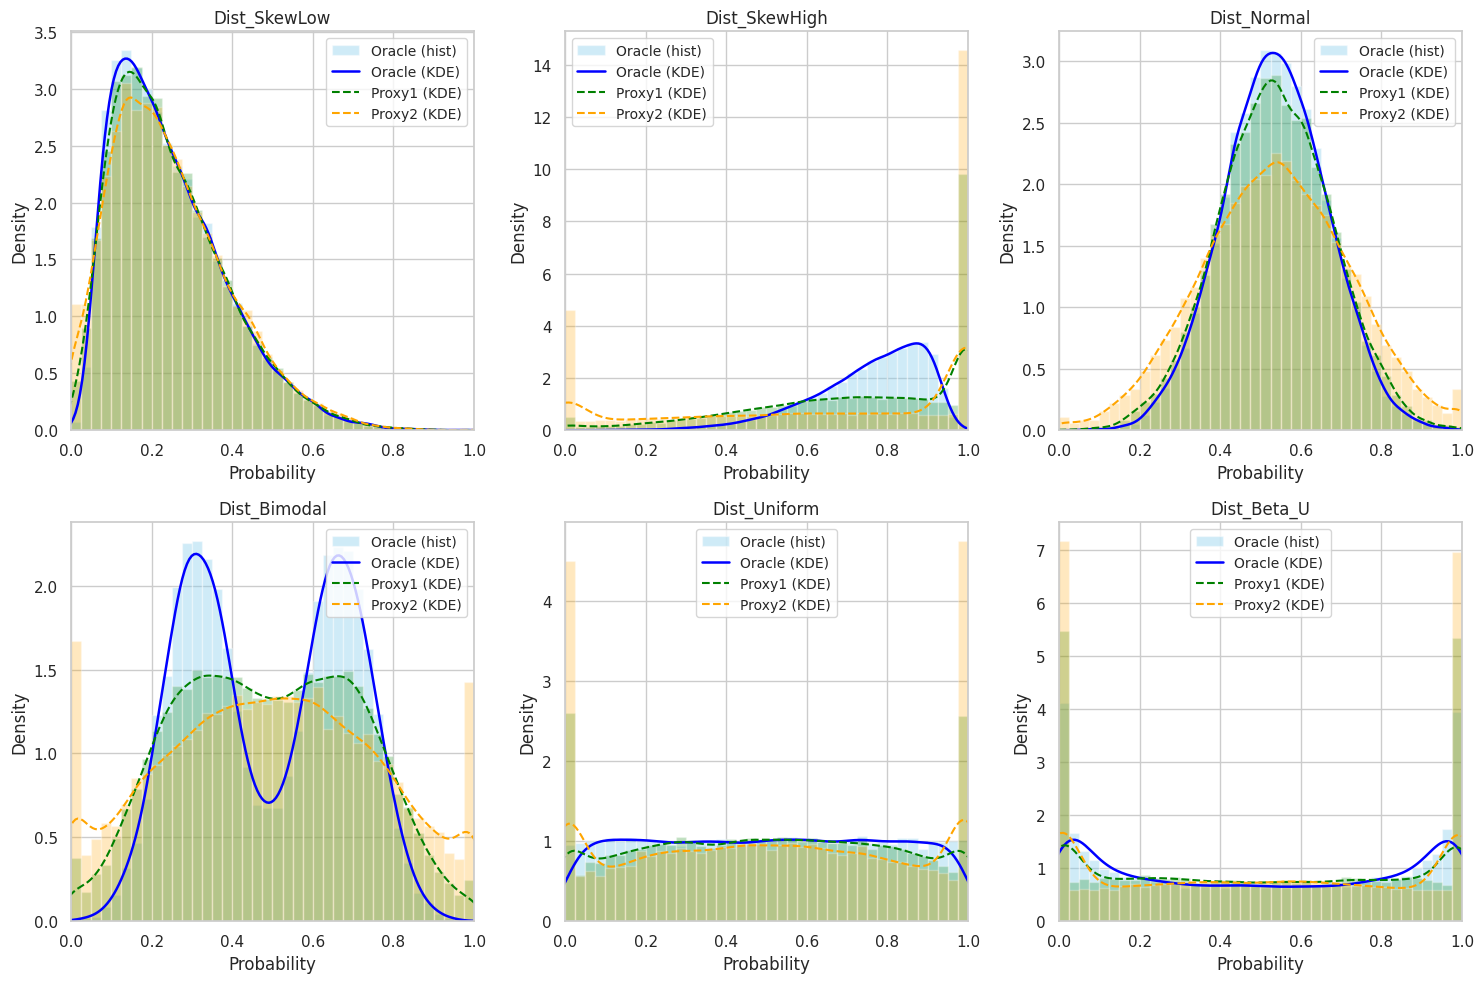


F1 Scores for Oracle and Proxies:
Dist_SkewLow_oracle_prob: Proxy1 F1=0.8865, Proxy2 F1=0.7992, Proxy3 F1=0.6461
Dist_SkewHigh_oracle_prob: Proxy1 F1=0.8885, Proxy2 F1=0.7942, Proxy3 F1=0.6487
Dist_Normal_oracle_prob: Proxy1 F1=0.8953, Proxy2 F1=0.7922, Proxy3 F1=0.6407
Dist_Bimodal_oracle_prob: Proxy1 F1=0.8950, Proxy2 F1=0.7999, Proxy3 F1=0.6420
Dist_Uniform_oracle_prob: Proxy1 F1=0.8936, Proxy2 F1=0.7997, Proxy3 F1=0.6397
Dist_Beta_U_oracle_prob: Proxy1 F1=0.8901, Proxy2 F1=0.7988, Proxy3 F1=0.6457

文件已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post_with_multi_distributions.csv


In [5]:
# 在 notebook 顶部添加（如果已添加则无需重复）
# 顶部 imports（把这段放在 notebook 的 imports 区）
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.stats import skewnorm
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DistributionGenerator:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = self._load_data()
        self.N = len(self.df)
        self.plot_cols = []

    def _load_data(self):
        """加载数据文件，如果不存在则生成示例数据"""
        try:
            df = pd.read_csv(self.file_path)
            print(f"成功读取 {self.file_path}，共 {len(df)} 行数据。")
        except FileNotFoundError:
            print("未找到文件，生成示例数据...")
            df = pd.DataFrame({'id': range(2000)})
        return df

    @staticmethod
    def normalize(data):
        """将任意分布归一化到 [0, 1]"""
        return (data - data.min()) / (data.max() - data.min())

    def generate_proxy_with_target_f1(self, oracle_probs, gt, target_f1_min, target_f1_max):
        """
        通过向 Oracle 添加噪声来生成 Proxy，直到 F1 分数落在目标区间内。
        为避免产生大量精确 0/1（绘图时导致尖锐柱状），使用 eps 截断并加微量 jitter。
        """
        sigma = 0.01
        eps = 1e-6  # 避免精确 0/1
        # 若 GT 单一类，直接返回（保护）
        if len(np.unique(gt)) < 2:
            print("Warning: Ground Truth has only one class. Returning original probs.")
            return oracle_probs

        proxy_probs = oracle_probs.copy()
        for i in range(200):
            noise = np.random.normal(0, sigma, size=len(oracle_probs))
            proxy_probs = oracle_probs + noise

            # 先 clip 到 [eps, 1-eps] 避免精确 0/1
            proxy_probs = np.clip(proxy_probs, eps, 1.0 - eps)

            # 额外加极小随机抖动以打散少量可能的重复值（防止直方图尖柱）
            jitter = np.random.uniform(-1e-7, 1e-7, size=len(proxy_probs))
            proxy_probs = np.clip(proxy_probs + jitter, eps, 1.0 - eps)

            proxy_pred = (proxy_probs > 0.5).astype(int)
            current_f1 = f1_score(gt, proxy_pred, zero_division=0)

            if target_f1_min <= current_f1 <= target_f1_max:
                return proxy_probs

            # 调整 sigma 使得搜索更稳健
            if current_f1 > target_f1_max:
                sigma *= 1.1
            elif current_f1 < target_f1_min:
                sigma *= 0.9

        # 若循环结束仍未满足，返回当前 proxy_probs（已做 eps/jitter 处理）
        return proxy_probs

    def process_distribution(self, name_prefix, raw_data):
        """
        处理单个分布的完整流程：归一化 -> 生成GT -> 生成3个Proxy -> 保存到df
        """
        # 1. 归一化得到 Oracle Probability
        oracle_prob = self.normalize(raw_data)
        col_oracle = f'{name_prefix}_oracle_prob'
        self.df[col_oracle] = oracle_prob
        
        # 2. 生成 Ground Truth
        gt = (oracle_prob > 0.5).astype(int)
        pos_rate = gt.mean()
        print(f"[{name_prefix}] Positive Rate: {pos_rate:.2%}")
        
        # 3. 生成 Proxies
        # Proxy 1: F1 > 0.85
        self.df[f'{name_prefix}_proxy1'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.85, 0.90)
        # Proxy 2: F1 > 0.75
        self.df[f'{name_prefix}_proxy2'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.75, 0.80)
        # Proxy 3: F1 > 0.6
        self.df[f'{name_prefix}_proxy3'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.60, 0.65)
        
        self.plot_cols.append(col_oracle)

    def generate_distributions(self):
        """生成多种分布"""
        print("开始生成多种分布...\n")

        # --- A. Skewed Low (右偏，低概率为主) ---
        raw_skew_low = skewnorm.rvs(a=10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewLow', raw_skew_low)

        # --- B. Skewed High (左偏，高概率为主) ---
        raw_skew_high = skewnorm.rvs(a=-10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewHigh', raw_skew_high)

        # --- C. Normal / Gaussian (正态分布，居中) ---
        raw_normal = np.random.normal(loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_Normal', raw_normal)

        # --- D. Bimodal (双峰分布，两极分化) ---
        dist1 = np.random.normal(-2, 1, int(self.N/2))
        dist2 = np.random.normal(2, 1, self.N - int(self.N/2))
        raw_bimodal = np.concatenate([dist1, dist2])
        np.random.shuffle(raw_bimodal)
        self.process_distribution('Dist_Bimodal', raw_bimodal)

        # --- E. Uniform (均匀分布) ---
        raw_uniform = np.random.uniform(0, 1, self.N)
        self.process_distribution('Dist_Uniform', raw_uniform)

        # --- F. Beta Distribution (U型分布，更极端的两极分化) ---
        raw_beta = np.random.beta(0.5, 0.5, size=self.N)
        self.process_distribution('Dist_Beta_U', raw_beta)

    def calculate_f1_scores(self):
        """计算每个 Oracle 对应的三个 Proxy 的 F1 分数"""
        print("\nF1 Scores for Oracle and Proxies:")
        for col_name in self.plot_cols:
            gt = (self.df[col_name] > 0.5).astype(int)
            proxy1_col = col_name.replace('oracle_prob', 'proxy1')
            proxy2_col = col_name.replace('oracle_prob', 'proxy2')
            proxy3_col = col_name.replace('oracle_prob', 'proxy3')
            
            f1_proxy1 = f1_score(gt, (self.df[proxy1_col] > 0.5).astype(int))
            f1_proxy2 = f1_score(gt, (self.df[proxy2_col] > 0.5).astype(int))
            f1_proxy3 = f1_score(gt, (self.df[proxy3_col] > 0.5).astype(int))
            
            print(f"{col_name}: Proxy1 F1={f1_proxy1:.4f}, Proxy2 F1={f1_proxy2:.4f}, Proxy3 F1={f1_proxy3:.4f}")

    def visualize_distributions(self, figsize=(15, 10), bins=40, kde_bw=None, show_hist=True):
        """
        对每个 oracle 分布，绘制 Oracle 与 Proxy1/2/3 的对比图（KDE + 可选直方图）。
        同时在控制台输出每个 Proxy 与 Oracle 的 KS 和 Wasserstein 指标。
        """
        if not hasattr(self, "plot_cols") or len(self.plot_cols) == 0:
            print("No distributions to plot. Please run generate_distributions() first.")
            return

        sns.set(style="whitegrid")

        n = len(self.plot_cols)
        cols = 3
        rows = (n + cols - 1) // cols
        plt.figure(figsize=(figsize[0], figsize[1] if isinstance(figsize, tuple) else figsize))
        for idx, col_name in enumerate(self.plot_cols):
            oracle_col = col_name
            proxy_cols = [col_name.replace('oracle_prob', f'proxy{j}') for j in (1, 2)]

            oracle = self.df[oracle_col].dropna().values
            proxies = [self.df[p].dropna().values for p in proxy_cols]

            ax = plt.subplot(rows, cols, idx + 1)

            # 背景直方图（Oracle）
            if show_hist:
                ax.hist(oracle, bins=bins, density=True, color='skyblue', alpha=0.4, label='Oracle (hist)')

            # KDE 叠加
            sns.kdeplot(oracle, bw_method=kde_bw, ax=ax, label='Oracle (KDE)', color='blue', linewidth=1.8)
            colors = ['green', 'orange', 'red']
            for j, (p_arr, color) in enumerate(zip(proxies, colors), start=1):
                if len(p_arr) == 0:
                    continue
                if show_hist:
                    ax.hist(p_arr, bins=bins, density=True, alpha=0.25, color=color)
                sns.kdeplot(p_arr, bw_method=kde_bw, ax=ax, label=f'Proxy{j} (KDE)', color=color, linestyle='--')

            ax.set_xlim(0, 1)
            ax.set_xlabel('Probability')
            ax.set_ylabel('Density')
            ax.set_title(col_name.replace('_oracle_prob', ''))
            ax.legend(fontsize='small')

            # 计算并打印相似度指标（控制台）
            print(f"\n--- Similarity metrics for {col_name} ---")
            for j, p_arr in enumerate(proxies, start=1):
                metrics = self.compute_similarity_metrics(oracle, p_arr)
                print(f"Proxy{j}: KS_stat={metrics['ks_stat']:.4f}, KS_p={metrics['ks_pvalue']:.4g}, Wasserstein={metrics['wasserstein']:.6f}")

        plt.tight_layout()
        plt.show()

        
        def save_distributions(self):
            """保存生成的分布到文件"""
            save_path = self.file_path.replace('post.csv', 'post_with_multi_distributions.csv')
            self.df.to_csv(save_path, index=False)
            print(f"\n文件已保存至: {save_path}")
    def compute_similarity_metrics(self, a: np.ndarray, b: np.ndarray):
        """计算两组概率分布的 KS stat 与 Wasserstein distance"""
        a = np.asarray(a).astype(float)
        b = np.asarray(b).astype(float)
        a = a[~np.isnan(a)]
        b = b[~np.isnan(b)]
        if len(a) == 0 or len(b) == 0:
            return {"ks_stat": np.nan, "ks_pvalue": np.nan, "wasserstein": np.nan}
        ks_res = ks_2samp(a, b)
        w = wasserstein_distance(a, b)
        return {"ks_stat": ks_res.statistic, "ks_pvalue": ks_res.pvalue, "wasserstein": w}

    def save_distributions(self):
        """保存生成的分布到文件"""
        save_path = self.file_path.replace('post.csv', 'post_with_multi_distributions.csv')
        self.df.to_csv(save_path, index=False)
        print(f"\n文件已保存至: {save_path}")
# 使用类
file_path = '/home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv'
generator = DistributionGenerator(file_path)
generator.generate_distributions()
# generator.visualize_distributions()
generator.visualize_distributions(figsize=(15, 10), bins=40, kde_bw=None, show_hist=True)
generator.calculate_f1_scores()  # 输出 F1 分数
generator.save_distributions()

### 1. V3.0 生成不同分布类型的函数
为post.csv文件生成一个oracle分布（偏斜正态分布，往低概率偏斜），列名为ML3_oracle_probility, 然后生成与ML3_oracle_probility 分布近似（考虑添加噪声、上下左右平移或者更复杂的处理方法）的 ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility，同时要求以ML3_oracle_probility>0.5为ground_truth,ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility 的F1 分数分别大于0.8,0.7,0.6,
写一个接口

成功读取 /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv，共 24082 行数据。
开始生成多种分布...

[Dist_SkewLow] Positive Rate: 3.14%
[Dist_SkewHigh] Positive Rate: 95.26%
[Dist_Normal] Positive Rate: 49.54%
[Dist_Bimodal] Positive Rate: 51.30%
[Dist_Uniform] Positive Rate: 49.77%
[Dist_Beta_U] Positive Rate: 49.89%

F1 Scores for Oracle and Proxies:
Dist_SkewLow_oracle_prob -> Proxy1: 0.8677 | Dist_SkewLow_oracle_prob -> Proxy2: 0.7766 | Dist_SkewLow_oracle_prob -> Proxy3: 0.6100 | 
Dist_SkewHigh_oracle_prob -> Proxy1: 0.8976 | Dist_SkewHigh_oracle_prob -> Proxy2: 0.7944 | Dist_SkewHigh_oracle_prob -> Proxy3: 0.6484 | 
Dist_Normal_oracle_prob -> Proxy1: 0.8505 | Dist_Normal_oracle_prob -> Proxy2: 0.7596 | Dist_Normal_oracle_prob -> Proxy3: 0.6460 | 
Dist_Bimodal_oracle_prob -> Proxy1: 0.8923 | Dist_Bimodal_oracle_prob -> Proxy2: 0.7998 | Dist_Bimodal_oracle_prob -> Proxy3: 0.6475 | 
Dist_Uniform_oracle_prob -> Proxy1: 0.8918 | Dist_Uniform_oracle_prob -> Proxy2: 0.7865 | Dist_

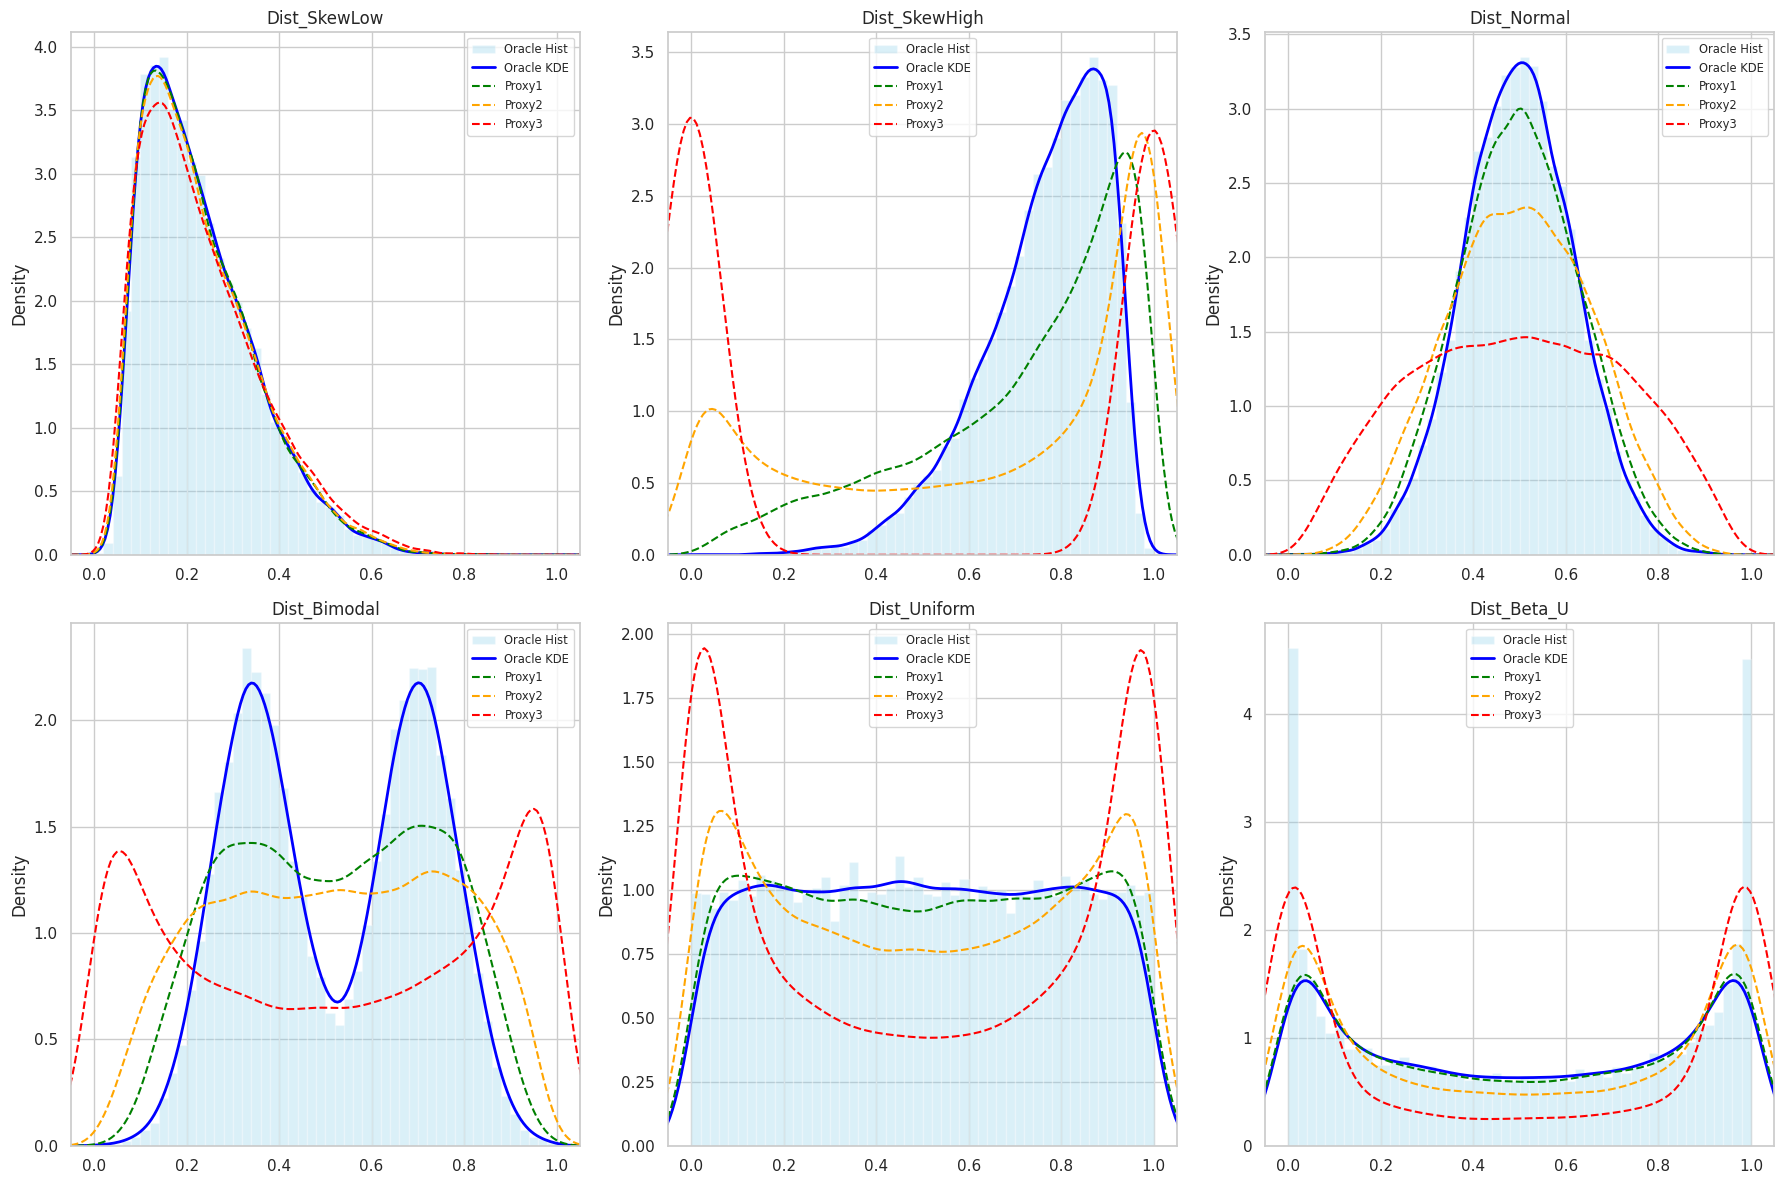


文件已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post_with_multi_distributions.csv


In [6]:
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, skewnorm
from scipy.special import expit, logit  # 引入 logit 和 sigmoid (expit)
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DistributionGenerator:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = self._load_data()
        self.N = len(self.df)
        self.plot_cols = []

    def _load_data(self):
        try:
            df = pd.read_csv(self.file_path)
            print(f"成功读取 {self.file_path}，共 {len(df)} 行数据。")
        except FileNotFoundError:
            print("未找到文件，生成示例数据...")
            df = pd.DataFrame({'id': range(2000)})
        return df

    @staticmethod
    def normalize(data):
        """将任意分布归一化到 [0, 1]"""
        return (data - data.min()) / (data.max() - data.min())

    def generate_proxy_with_target_f1(self, oracle_probs, gt, target_f1_min, target_f1_max):
        """
        使用 Logit-Normal 变换生成平滑的 Proxy 分布，避免 0/1 处堆积。
        """
        # 1. 预处理：避免 logit 输入为精确的 0 或 1
        eps = 1e-5
        # 将 oracle 限制在 (eps, 1-eps) 之间，保证 logit 不会爆出 inf
        clipped_oracle = np.clip(oracle_probs, eps, 1 - eps)
        
        # 2. 转换到 Logit 空间 (-inf, +inf)
        oracle_logits = logit(clipped_oracle)

        # GT 检查
        if len(np.unique(gt)) < 2:
            return oracle_probs

        # 初始噪声强度 (Logit 空间下的 sigma 通常比概率空间大，初始设为 0.5 左右)
        sigma = 0.5 
        
        best_proxy = None
        best_diff = float('inf')

        # 尝试寻找合适的噪声水平
        for i in range(200):
            # 在 Logit 空间加噪声
            noise = np.random.normal(0, sigma, size=len(oracle_logits))
            noisy_logits = oracle_logits + noise
            
            # 还原回概率空间 [0, 1]
            proxy_probs = expit(noisy_logits)

            # 计算 F1
            proxy_pred = (proxy_probs > 0.5).astype(int)
            current_f1 = f1_score(gt, proxy_pred, zero_division=0)

            # 记录最接近的一次（以防循环结束没命中区间）
            diff = abs(current_f1 - (target_f1_min + target_f1_max) / 2)
            if diff < best_diff:
                best_diff = diff
                best_proxy = proxy_probs

            # 判断是否满足目标区间
            if target_f1_min <= current_f1 <= target_f1_max:
                return proxy_probs

            # 动态调整 Sigma
            if current_f1 > target_f1_max:
                # F1 太高 -> 说明噪声太小 -> 增大 Sigma
                sigma *= 1.1
            elif current_f1 < target_f1_min:
                # F1 太低 -> 说明噪声太大 -> 减小 Sigma
                sigma *= 0.9

        # 如果没找到完美区间的，返回最接近的
        return best_proxy

    def process_distribution(self, name_prefix, raw_data):
        """处理单个分布的完整流程"""
        # 1. 归一化得到 Oracle Probability
        oracle_prob = self.normalize(raw_data)
        col_oracle = f'{name_prefix}_oracle_prob'
        self.df[col_oracle] = oracle_prob
        
        # 2. 生成 Ground Truth
        gt = (oracle_prob > 0.5).astype(int)
        pos_rate = gt.mean()
        print(f"[{name_prefix}] Positive Rate: {pos_rate:.2%}")
        
        # 3. 生成 Proxies (F1 目标不变)
        self.df[f'{name_prefix}_proxy1'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.85, 0.90)
        self.df[f'{name_prefix}_proxy2'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.75, 0.80)
        self.df[f'{name_prefix}_proxy3'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.60, 0.65)
        
        self.plot_cols.append(col_oracle)

    def generate_distributions(self):
        print("开始生成多种分布...\n")
        # --- A. Skewed Low ---
        raw_skew_low = skewnorm.rvs(a=10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewLow', raw_skew_low)

        # --- B. Skewed High ---
        raw_skew_high = skewnorm.rvs(a=-10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewHigh', raw_skew_high)

        # --- C. Normal ---
        raw_normal = np.random.normal(loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_Normal', raw_normal)

        # --- D. Bimodal ---
        dist1 = np.random.normal(-2, 1, int(self.N/2))
        dist2 = np.random.normal(2, 1, self.N - int(self.N/2))
        raw_bimodal = np.concatenate([dist1, dist2])
        np.random.shuffle(raw_bimodal)
        self.process_distribution('Dist_Bimodal', raw_bimodal)

        # --- E. Uniform ---
        raw_uniform = np.random.uniform(0, 1, self.N)
        self.process_distribution('Dist_Uniform', raw_uniform)

        # --- F. Beta Distribution ---
        raw_beta = np.random.beta(0.5, 0.5, size=self.N)
        self.process_distribution('Dist_Beta_U', raw_beta)

    def calculate_f1_scores(self):
        print("\nF1 Scores for Oracle and Proxies:")
        for col_name in self.plot_cols:
            gt = (self.df[col_name] > 0.5).astype(int)
            for i in range(1, 4):
                p_col = col_name.replace('oracle_prob', f'proxy{i}')
                f1 = f1_score(gt, (self.df[p_col] > 0.5).astype(int))
                print(f"{col_name} -> Proxy{i}: {f1:.4f}", end=" | ")
            print()

    def visualize_distributions(self, figsize=(18, 12), bins=50, kde_bw=None, show_hist=True):
        if not hasattr(self, "plot_cols") or len(self.plot_cols) == 0:
            return

        sns.set(style="whitegrid")
        n = len(self.plot_cols)
        cols = 3
        rows = (n + cols - 1) // cols
        plt.figure(figsize=figsize)
        
        for idx, col_name in enumerate(self.plot_cols):
            oracle_col = col_name
            proxy_cols = [col_name.replace('oracle_prob', f'proxy{j}') for j in range(1, 4)]
            
            oracle = self.df[oracle_col].dropna().values
            
            ax = plt.subplot(rows, cols, idx + 1)

            # 绘制 Oracle (Histogram + KDE)
            if show_hist:
                ax.hist(oracle, bins=bins, density=True, color='skyblue', alpha=0.3, label='Oracle Hist')
            sns.kdeplot(oracle, bw_method=kde_bw, ax=ax, label='Oracle KDE', color='blue', linewidth=2)
            
            # 绘制 Proxies
            colors = ['green', 'orange', 'red']
            for j, (p_name, color) in enumerate(zip(proxy_cols, colors), start=1):
                p_vals = self.df[p_name].dropna().values
                sns.kdeplot(p_vals, bw_method=kde_bw, ax=ax, label=f'Proxy{j}', color=color, linestyle='--')
            
            ax.set_xlim(-0.05, 1.05)
            ax.set_title(col_name.replace('_oracle_prob', ''))
            ax.legend(fontsize='x-small')

        plt.tight_layout()
        plt.show()

    def compute_similarity_metrics(self, a, b):
        a = np.asarray(a).astype(float)
        b = np.asarray(b).astype(float)
        if len(a) == 0 or len(b) == 0: return {}
        ks_res = ks_2samp(a, b)
        w = wasserstein_distance(a, b)
        return {"ks": ks_res.statistic, "w": w}

    def save_distributions(self):
        save_path = self.file_path.replace('post.csv', 'post_with_multi_distributions.csv')
        self.df.to_csv(save_path, index=False)
        print(f"\n文件已保存至: {save_path}")

# ================= 运行代码 =================
file_path = '/home/wangshuo/resource/datasets/parler_data/dataset_one/csv_data/post.csv'
generator = DistributionGenerator(file_path)
generator.generate_distributions()
generator.calculate_f1_scores()
generator.visualize_distributions() # 此时画出的图，边缘应该非常平滑
generator.save_distributions()

### 1. V4.0 生成不同分布类型的函数 
（1）为post.csv文件生成一个oracle分布（偏斜正态分布，往低概率偏斜），列名为ML3_oracle_probility, 然后生成与ML3_oracle_probility 分布近似（考虑添加噪声、上下左右平移或者更复杂的处理方法）的 ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility，同时要求以ML3_oracle_probility>0.5为ground_truth,ML3_proxy1_probility，ML3_proxy2_probility，ML3_proxy3_probility 的F1 分数分别大于0.8,0.7,0.6,
（2）控制每种分布>0.5的比率，除了Dist_SkewLow 和 Dist_SkewHigh 外，所有分布的>0.5的比率约等于50%，除了uniform外，我想通过手动控制，Dist_SkewLow，Dist_SkewHigh，Dist_Normal，Dist_Bimodal，Dist_Beta_U 分布大于 x（默认为0.5）的比率，怎么实现（平移？），再添加一个分布，就是两端分布多，类似Dist_Beta_U  ，但是两端也有差距，可以由我设定谁高谁低

成功读取 /home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv，共 24082 行数据。
开始生成多种分布...

   -> 调整 Dist_SkewLow 正例率至 11.0%...
[Dist_SkewLow] Final Positive Rate: 11.00%

F1 Scores for Oracle and Proxies:
Dist_SkewLow_oracle_prob -> Proxy1: 0.8776 | Dist_SkewLow_oracle_prob -> Proxy2: 0.8167 | Dist_SkewLow_oracle_prob -> Proxy3: 0.7328 | Dist_SkewLow_oracle_prob -> Proxy4: 0.6209 | 


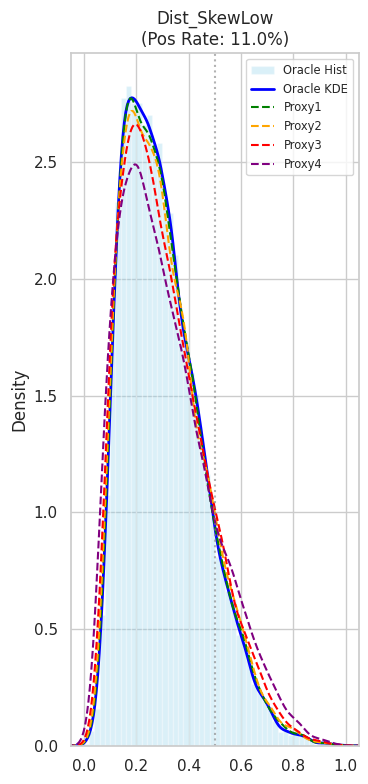


文件已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv


In [2]:
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, skewnorm
from scipy.special import expit, logit
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DistributionGenerator:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = self._load_data()
        self.N = len(self.df)
        self.plot_cols = []

    def _load_data(self):
        try:
            df = pd.read_csv(self.file_path)
            print(f"成功读取 {self.file_path}，共 {len(df)} 行数据。")
        except FileNotFoundError:
            print("未找到文件，生成示例数据...")
            df = pd.DataFrame({'id': range(2000)})
        return df

    @staticmethod
    def normalize(data):
        """将任意分布归一化到 [0, 1]"""
        return (data - data.min()) / (data.max() - data.min())

    def adjust_positive_rate(self, probs, target_rate=0.5):
        """
        通过幂变换（Gamma Correction）调整分布，使得大于 0.5 的比率等于 target_rate。
        比线性平移更好，因为它不会导致 0 或 1 处的截断堆积。
        
        原理：寻找 gamma 使得 P(x^gamma > 0.5) = target_rate
        即：原分布的 (1 - target_rate) 分位点 映射到 0.5
        """
        # 1. 找到当前数据中对应 target_rate 的分位数值
        # 例如：要 50% 的人 > 0.5，则中位数（0.5分位点）应该映射到 0.5
        # 例如：要 20% 的人 > 0.5，则 80%分位点（0.8）应该映射到 0.5
        quantile_needed = 1.0 - target_rate
        current_val_at_quantile = np.quantile(probs, quantile_needed)
        
        # 避免数值问题
        current_val_at_quantile = np.clip(current_val_at_quantile, 1e-9, 1.0 - 1e-9)
        
        # 2. 计算 Gamma 值: val ^ gamma = 0.5  => gamma = log(0.5) / log(val)
        gamma = np.log(0.5) / np.log(current_val_at_quantile)
        
        # 3. 应用变换
        new_probs = np.power(probs, gamma)
        return new_probs

    def generate_proxy_with_target_f1(self, oracle_probs, gt, target_f1_min, target_f1_max):
        """Logit-Normal 变换生成平滑 Proxy"""
        eps = 1e-5
        clipped_oracle = np.clip(oracle_probs, eps, 1 - eps)
        oracle_logits = logit(clipped_oracle)

        if len(np.unique(gt)) < 2:
            return oracle_probs

        sigma = 0.5 
        best_proxy = None
        best_diff = float('inf')

        for i in range(200):
            noise = np.random.normal(0, sigma, size=len(oracle_logits))
            noisy_logits = oracle_logits + noise
            proxy_probs = expit(noisy_logits) # sigmoid

            proxy_pred = (proxy_probs > 0.5).astype(int)
            current_f1 = f1_score(gt, proxy_pred, zero_division=0)

            diff = abs(current_f1 - (target_f1_min + target_f1_max) / 2)
            if diff < best_diff:
                best_diff = diff
                best_proxy = proxy_probs

            if target_f1_min <= current_f1 <= target_f1_max:
                return proxy_probs

            if current_f1 > target_f1_max:
                sigma *= 1.1
            elif current_f1 < target_f1_min:
                sigma *= 0.9

        return best_proxy

    def process_distribution(self, name_prefix, raw_data, target_pos_rate=None):
        """
        raw_data: 原始数据
        target_pos_rate: 期望的正例率（>0.5的比率）。如果为None，则保持原样。
        """
        # 1. 基础归一化
        # oracle_prob = self.normalize(raw_data)
        raw = np.asarray(raw_data)
        if raw.size > 0 and raw.min() >= 0.0 and raw.max() <= 1.0:
            oracle_prob = raw.copy()
        else:
            oracle_prob = self.normalize(raw)
        
        # 2. 如果指定了目标比率，进行调整
        if target_pos_rate is not None:
            print(f"   -> 调整 {name_prefix} 正例率至 {target_pos_rate*100}%...")
            oracle_prob = self.adjust_positive_rate(oracle_prob, target_pos_rate)

        col_oracle = f'{name_prefix}_oracle_prob'
        self.df[col_oracle] = oracle_prob
        
        # 3. 生成 Ground Truth
        gt = (oracle_prob > 0.5).astype(int)
        pos_rate = gt.mean()
        print(f"[{name_prefix}] Final Positive Rate: {pos_rate:.2%}")
        
        # 4. 生成 Proxies
        self.df[f'{name_prefix}_proxy1'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.87, 0.91)
        self.df[f'{name_prefix}_proxy2'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.80, 0.85)
        self.df[f'{name_prefix}_proxy3'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.70, 0.75)
        self.df[f'{name_prefix}_proxy4'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.60, 0.65)
        
        self.plot_cols.append(col_oracle)

    def generate_bimodal(self,
                     N,
                     peak_sep=0.5,
                     concentration=60,
                     left_weight=0.5,
                     valley_strength=0.0,
                     valley_width=0.08,
                     peak_center=0.5,
                     oversample_factor=2):
        """
        在概率域生成双峰分布（返回值在 [0,1]）。
        参数：
        - N: 目标样本数量
        - peak_sep: 两峰在概率轴上的间距（0..1）。两个峰位于:
                    left = peak_center - peak_sep/2, right = peak_center + peak_sep/2
        - concentration: Beta 分布浓度参数（越大峰越尖）
        - left_weight: 左峰权重(0..1)，右峰权重 = 1-left_weight
        - valley_strength: 在概率轴中心（peak_center）对中间值的抑制强度 (0..1)
        - valley_width: 谷的宽度（概率轴上的 std）
        - peak_center: 两峰中点位置（通常 0.5），可移动使峰远离 0.5
        - oversample_factor: 候选池倍数，用于拒绝采样（>1）
        返回：
        numpy array (长度为 N) 的概率值（0..1）
        """
        import numpy as _np

        eps = 1e-6
        if N <= 0:
            return _np.array([])

        # 计算左右峰的期望（概率空间）
        half = float(peak_sep) / 2.0
        left_mean = max(eps, min(1.0 - eps, peak_center - half))
        right_mean = max(eps, min(1.0 - eps, peak_center + half))

        # Beta 参数： alpha = mean * conc, beta = (1-mean) * conc
        conc = max(1.0, float(concentration))
        a_left, b_left = left_mean * conc, (1.0 - left_mean) * conc
        a_right, b_right = right_mean * conc, (1.0 - right_mean) * conc

        # 先生成候选池（防止拒绝采样不足）
        pool_size = max(int(N * oversample_factor), N + 10)
        # 决定来自哪峰
        choices = _np.random.choice([0, 1], size=pool_size, p=[left_weight, 1.0 - left_weight])
        left_n = int((choices == 0).sum())
        right_n = pool_size - left_n

        # 从 Beta 采样（直接在概率域）
        left_samples = _np.random.beta(a_left + eps, b_left + eps, size=left_n) if left_n > 0 else _np.array([])
        right_samples = _np.random.beta(a_right + eps, b_right + eps, size=right_n) if right_n > 0 else _np.array([])

        pool = _np.empty(pool_size, dtype=float)
        pool[choices == 0] = left_samples
        pool[choices == 1] = right_samples

        # 如果无 valley 抑制，直接随机抽取 N 个返回
        if valley_strength <= 0.0:
            if pool_size == N:
                samples = pool
            else:
                idx = _np.random.choice(pool_size, size=N, replace=False)
                samples = pool[idx]
            _np.random.shuffle(samples)
            return samples

        # 否则，对靠近 peak_center 的点按 keep_prob 进行拒绝采样（抑制中心）
        x = pool
        # keep_prob 最大为 1，最小不小于0
        keep_prob = 1.0 - float(valley_strength) * _np.exp(- ((x - peak_center) ** 2) / (2.0 * (valley_width ** 2)))
        keep_prob = _np.clip(keep_prob, 0.0, 1.0)

        u = _np.random.rand(pool_size)
        kept = pool[u <= keep_prob]

        # 如果不足 N，做增量补样（最多几次），最后回退到非抑制补齐以保证 N 个输出
        if len(kept) < N:
            attempts = 0
            max_attempts = 5
            while len(kept) < N and attempts < max_attempts:
                attempts += 1
                extra_size = int(N * 0.5 * attempts) + 10
                choices = _np.random.choice([0,1], size=extra_size, p=[left_weight, 1.0-left_weight])
                left_n = int((choices == 0).sum()); right_n = extra_size - left_n
                left_s = _np.random.beta(a_left + eps, b_left + eps, size=left_n) if left_n>0 else _np.array([])
                right_s = _np.random.beta(a_right + eps, b_right + eps, size=right_n) if right_n>0 else _np.array([])
                extra_pool = _np.empty(extra_size, dtype=float)
                extra_pool[choices==0] = left_s
                extra_pool[choices==1] = right_s
                kp = 1.0 - float(valley_strength) * _np.exp(- ((extra_pool - peak_center) ** 2) / (2.0 * (valley_width ** 2)))
                kp = _np.clip(kp, 0.0, 1.0)
                u = _np.random.rand(extra_size)
                extra_kept = extra_pool[u <= kp]
                if extra_kept.size > 0:
                    kept = _np.concatenate([kept, extra_kept])

            # 仍不足则用非抑制的候选补齐
            if len(kept) < N:
                need = N - len(kept)
                # 从最初 pool 中补（不按 keep_prob）
                extra_idx = _np.random.choice(pool_size, size=min(need, pool_size), replace=True)
                kept = _np.concatenate([kept, pool[extra_idx]])
                # 若仍不足（极端），重复取 kept 元素
                if len(kept) < N:
                    extra_fill = _np.random.choice(kept, size=(N - len(kept)), replace=True)
                    kept = _np.concatenate([kept, extra_fill])

        # 随机挑选 N 个
        if len(kept) >= N:
            idx = _np.random.choice(len(kept), size=N, replace=False)
            samples = kept[idx]
        else:
            # 极端退回（保证返回长度）
            samples = _np.random.choice(pool, size=N, replace=True)

        _np.random.shuffle(samples)
        return samples
   
    def generate_distributions(self):
        print("开始生成多种分布...\n")
        
        # 1. Skewed Low (右偏) - 保持原样 (通常 Pos Rate 很低)
        raw_skew_low = skewnorm.rvs(a=10, loc=0, scale=1, size=self.N)
        self.process_distribution('Dist_SkewLow', raw_skew_low, target_pos_rate=0.11)

        # 2. Skewed High (左偏) - 保持原样 (通常 Pos Rate 很高)
        # raw_skew_high = skewnorm.rvs(a=-10, loc=0, scale=1, size=self.N)
        # self.process_distribution('Dist_SkewHigh', raw_skew_high, target_pos_rate=0.95)

        # # 3. Normal (正态) - 强制 50%
        # raw_normal = np.random.normal(loc=0, scale=1, size=self.N)
        # self.process_distribution('Dist_Normal', raw_normal, target_pos_rate=0.2)

        # #4. Bimodal Symmetric (双峰，对称) - 强制 50%
        # raw_bimodal1 = self.generate_bimodal(
        # N=self.N,
        # peak_sep=0.8,        # 两峰间距，接近1表示两峰尽可能远；示例 0.8
        # concentration=80,    # 峰越尖，越集中
        # left_weight=0.5,    # 左峰比右峰高（0.6 vs 0.4），若想完全对称设为0.5
        # valley_strength=0.3, # 在中心抑制强度 (0..1)，0 表示无抑制
        # valley_width=0.1,    # 谷的宽度，数值越小抑制越窄（更集中在中间）
        # peak_center=0.5,     # 中心点
        # oversample_factor=3  # 候选池倍数，默认 3
        # )
        # self.process_distribution('Dist_Bimodal_origin', raw_bimodal1, target_pos_rate=None)

        # # 4a. Bimodal (双峰) - 强制 50%
        # raw_bimodal1 = self.generate_bimodal(
        # N=self.N,
        # peak_sep=0.8,        # 两峰间距，接近1表示两峰尽可能远；示例 0.8
        # concentration=80,    # 峰越尖，越集中
        # left_weight=0.9,    # 左峰比右峰高（0.6 vs 0.4），若想完全对称设为0.5
        # valley_strength=0.5, # 在中心抑制强度 (0..1)，0 表示无抑制
        # valley_width=0.05,    # 谷的宽度，数值越小抑制越窄（更集中在中间）
        # peak_center=0.5,     # 中心点
        # oversample_factor=3  # 候选池倍数，默认 3
        # )
        # self.process_distribution('Dist_Bimodal_left', raw_bimodal1, target_pos_rate=None)

        
        # # 4b. Bimodal Left High (双峰，左峰更高) - 强制 50%
        # raw_bimodal2 = self.generate_bimodal(
        # N=self.N,
        # peak_sep=0.8,        # 两峰间距，接近1表示两峰尽可能远；示例 0.8
        # concentration=80,    # 峰越尖，越集中
        # left_weight=0.1,    # 左峰比右峰低（0.6 vs 0.4），若想完全对称设为0.5
        # valley_strength=0.6, # 在中心抑制强度 (0..1)，0 表示无抑制
        # valley_width=0.06,    # 谷的宽度，数值越小抑制越窄（更集中在中间）
        # peak_center=0.5,       # 中心点
        # oversample_factor=3  # 候选池倍数，默认 3
        # )
        # self.process_distribution('Dist_Bimodal_right', raw_bimodal2, target_pos_rate=None)


        # # 5. Uniform (均匀) - 保持自然 (大约50%，也可以强制)
        # raw_uniform = np.random.uniform(0, 1, self.N)
        # self.process_distribution('Dist_Uniform', raw_uniform, target_pos_rate=0.5)

        # 6. Beta U (对称U型) - 强制 50%
        # Beta(0.5, 0.5) 是经典的对称 U 型
        # raw_beta = np.random.beta(0.5, 0.5, size=self.N)
        # self.process_distribution('Dist_Beta_U', raw_beta, target_pos_rate=0.5)

        # ==========================================
        # 7. 新增: 不对称 U 型 (Dist_Asym_U)
        # ==========================================
        # 通过 Beta 分布参数控制两端高低
        # alpha < 1, beta < 1 保证是 U 型 (两端翘起)
        # alpha < beta -> 靠近 0 的密度更大 (Left High)
        # alpha > beta -> 靠近 1 的密度更大 (Right High)
        
        # Case A: 左端(0) 极高，右端(1) 较高 (整体偏低)
        # 设定 target_pos_rate 来控制切分点，或者完全由参数决定
        # 这里演示由参数决定形状，如果不满意正例率，可以再传参调整
        # raw_asym_left = np.random.beta(0.2, 0.5, size=self.N) 
        # # 这里我不强制 target_pos_rate，让你看到自然的非对称效果
        # # 如果你想让它非对称但正好一半一半，可以传 0.5
        # self.process_distribution('Dist_Asym_LeftHigh', raw_asym_left, target_pos_rate=0.1) # 稍微偏少一点正例

        # Case B: 右端(1) 极高，左端(0) 较高 (整体偏高)
        # raw_asym_right = np.random.beta(0.5, 0.2, size=self.N)
        # self.process_distribution('Dist_Asym_RightHigh', raw_asym_right, target_pos_rate=0.7) # 稍微偏多一点正例


    def calculate_f1_scores(self):
        print("\nF1 Scores for Oracle and Proxies:")
        for col_name in self.plot_cols:
            gt = (self.df[col_name] > 0.5).astype(int)
            for i in range(1, 5):
                p_col = col_name.replace('oracle_prob', f'proxy{i}')
                f1 = f1_score(gt, (self.df[p_col] > 0.5).astype(int))
                print(f"{col_name} -> Proxy{i}: {f1:.4f}", end=" | ")
            print()

    def visualize_distributions(self, figsize=(10, 8), bins=50, kde_bw=None, show_hist=True):
        if not hasattr(self, "plot_cols") or len(self.plot_cols) == 0:
            return

        sns.set(style="whitegrid")
        n = len(self.plot_cols)
        cols = 3
        rows = (n + cols - 1) // cols
        plt.figure(figsize=figsize)
        
        for idx, col_name in enumerate(self.plot_cols):
            oracle_col = col_name
            proxy_cols = [col_name.replace('oracle_prob', f'proxy{j}') for j in range(1, 5)]
            
            oracle = self.df[oracle_col].dropna().values
            
            ax = plt.subplot(rows, cols, idx + 1)

            # Oracle
            if show_hist:
                ax.hist(oracle, bins=bins, density=True, color='skyblue', alpha=0.3, label='Oracle Hist')
            sns.kdeplot(oracle, bw_method=kde_bw, ax=ax, label='Oracle KDE', color='blue', linewidth=2)
            
            # Proxies
            colors = ['green', 'orange', 'red','purple']
            for j, (p_name, color) in enumerate(zip(proxy_cols, colors), start=1):
                p_vals = self.df[p_name].dropna().values
                sns.kdeplot(p_vals, bw_method=kde_bw, ax=ax, label=f'Proxy{j}', color=color, linestyle='--')
            
            # 标出 0.5 分界线
            ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6)
            
            # 显示当前正例率
            pos_rate = (oracle > 0.5).mean()
            ax.set_title(f"{col_name.replace('_oracle_prob', '')}\n(Pos Rate: {pos_rate:.1%})")
            ax.set_xlim(-0.05, 1.05)
            ax.legend(fontsize='x-small')

        plt.tight_layout()
        plt.show()

    def save_distributions(self):
        save_path = self.file_path.replace('post.csv', 'post.csv')
        self.df.to_csv(save_path, index=False)
        print(f"\n文件已保存至: {save_path}")



# ================= 运行代码 =================
dataset = 'dataset_three'
file_name = 'post.csv'
file_path = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/csv_data/{file_name}'
generator = DistributionGenerator(file_path)

# samps = generator.generate_bimodal(10000, peak_sep=0.8, concentration=80, left_weight=0.6, valley_strength=0.5, valley_width=0.05)
# plt.hist(samps, bins=200, density=True)
# plt.xlim(0,1)
# plt.show()

# 生成分布
generator.generate_distributions()

# 计算并打印 F1
generator.calculate_f1_scores()

# 绘图 (注意看标题上的 Pos Rate 是否符合预期)
generator.visualize_distributions()

# 保存
generator.save_distributions()

### 1. V4.1 生成特定分布类型（极端分布）的函数 

成功读取 /home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv，共 24082 行数据。
开始生成多种分布...

Generating Dist_Extreme_Mix: Left=98.0%, Right=1.0%
[Dist_Extreme_Mix] Final Positive Rate: 1.47%

F1 Scores for Oracle and Proxies:
Dist_Extreme_Mix_oracle_prob -> Proxy1: 0.8853 | Dist_Extreme_Mix_oracle_prob -> Proxy2: 0.8029 | Dist_Extreme_Mix_oracle_prob -> Proxy3: 0.7028 | Dist_Extreme_Mix_oracle_prob -> Proxy4: 0.6435 | 


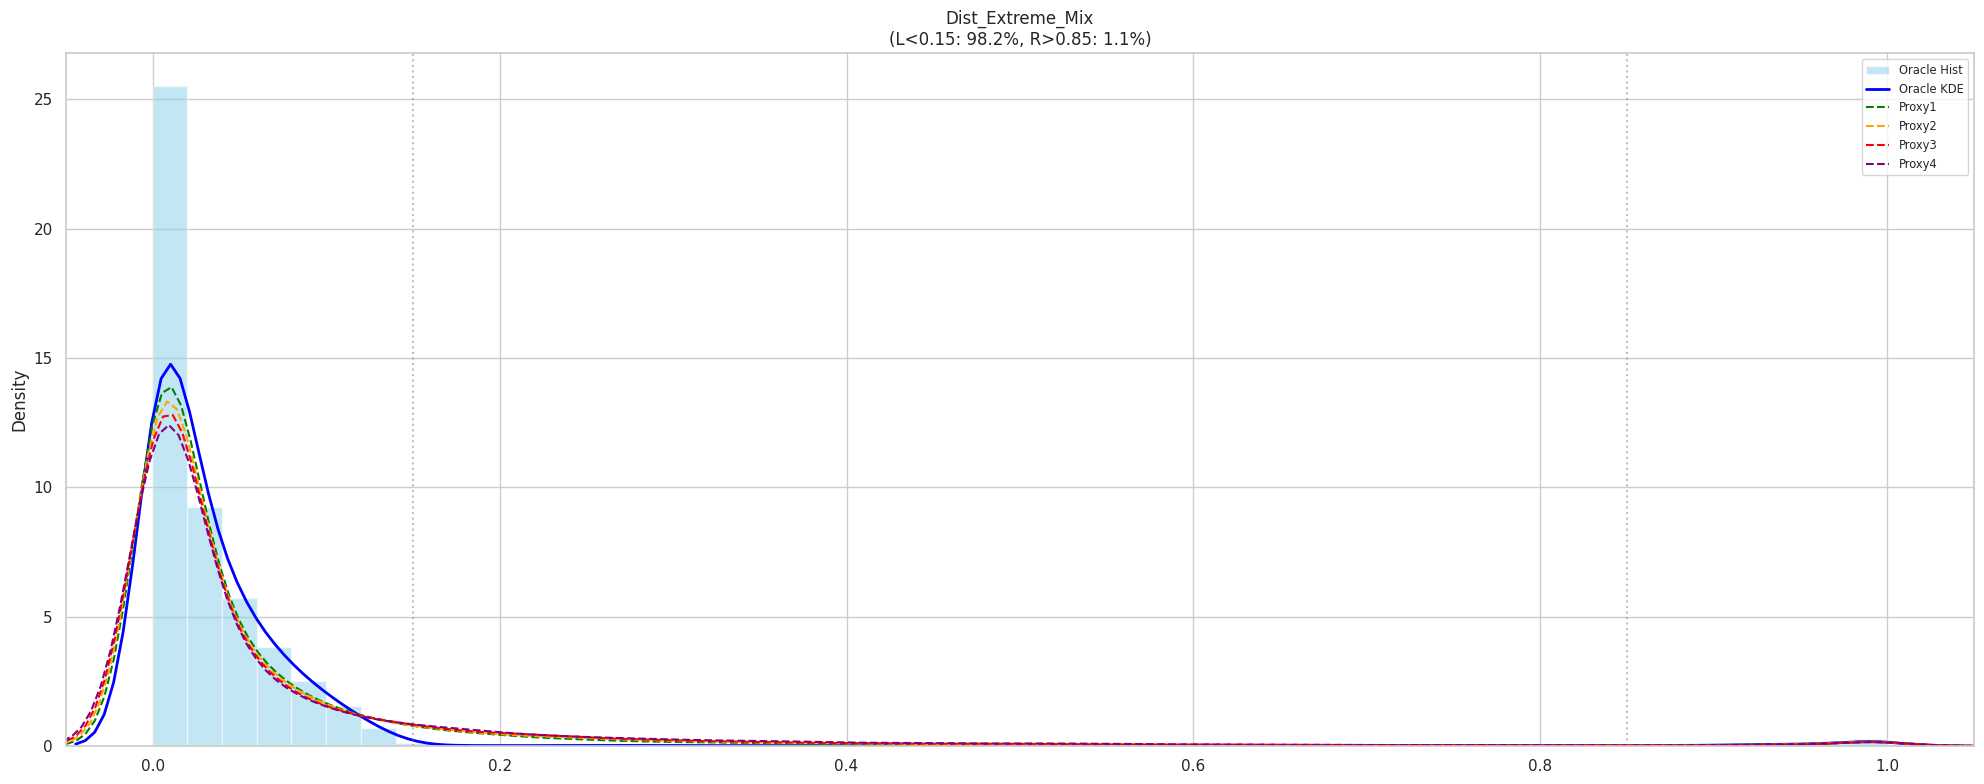


文件已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv


In [24]:
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, skewnorm
from scipy.special import expit, logit
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class DistributionGenerator:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = self._load_data()
        self.N = len(self.df)
        self.plot_cols = []

    def _load_data(self):
        try:
            df = pd.read_csv(self.file_path)
            print(f"成功读取 {self.file_path}，共 {len(df)} 行数据。")
        except FileNotFoundError:
            print("未找到文件，生成示例数据...")
            df = pd.DataFrame({'id': range(2000)})
        return df

    @staticmethod
    def normalize(data):
        """将任意分布归一化到 [0, 1]"""
        # 避免分母为0
        if data.max() == data.min():
            return data
        return (data - data.min()) / (data.max() - data.min())

    def adjust_positive_rate(self, probs, target_rate=0.5):
        """Gamma Correction 调整正例率"""
        quantile_needed = 1.0 - target_rate
        current_val_at_quantile = np.quantile(probs, quantile_needed)
        current_val_at_quantile = np.clip(current_val_at_quantile, 1e-9, 1.0 - 1e-9)
        gamma = np.log(0.5) / np.log(current_val_at_quantile)
        new_probs = np.power(probs, gamma)
        return new_probs

    def generate_proxy_with_target_f1(self, oracle_probs, gt, target_f1_min, target_f1_max):
        """Logit-Normal 变换生成平滑 Proxy"""
        eps = 1e-5
        clipped_oracle = np.clip(oracle_probs, eps, 1 - eps)
        oracle_logits = logit(clipped_oracle)

        if len(np.unique(gt)) < 2:
            return oracle_probs

        sigma = 0.5 
        best_proxy = None
        best_diff = float('inf')

        for i in range(200):
            noise = np.random.normal(0, sigma, size=len(oracle_logits))
            noisy_logits = oracle_logits + noise
            proxy_probs = expit(noisy_logits) 

            proxy_pred = (proxy_probs > 0.5).astype(int)
            current_f1 = f1_score(gt, proxy_pred, zero_division=0)

            diff = abs(current_f1 - (target_f1_min + target_f1_max) / 2)
            if diff < best_diff:
                best_diff = diff
                best_proxy = proxy_probs

            if target_f1_min <= current_f1 <= target_f1_max:
                return proxy_probs

            if current_f1 > target_f1_max:
                sigma *= 1.1
            elif current_f1 < target_f1_min:
                sigma *= 0.9

        return best_proxy

    def process_distribution(self, name_prefix, raw_data, target_pos_rate=None):
        """处理单个分布"""
        # 1. 归一化
        oracle_prob = self.normalize(raw_data)
        
        # 2. 如果指定了 target_pos_rate，进行 Gamma 调整
        # 注意：对于自定义混合分布(Custom Mix)，通常不建议再做 adjust_positive_rate，
        # 因为那会破坏我们精心设置的 [0, 0.15] 边界。
        if target_pos_rate is not None:
            print(f"   -> 调整 {name_prefix} 正例率至 {target_pos_rate*100}%...")
            oracle_prob = self.adjust_positive_rate(oracle_prob, target_pos_rate)

        col_oracle = f'{name_prefix}_oracle_prob'
        self.df[col_oracle] = oracle_prob
        
        # 3. 生成 GT
        gt = (oracle_prob > 0.5).astype(int)
        pos_rate = gt.mean()
        print(f"[{name_prefix}] Final Positive Rate: {pos_rate:.2%}")
        
        # 4. 生成 Proxies
        self.df[f'{name_prefix}_proxy1'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.87, 0.91)
        self.df[f'{name_prefix}_proxy2'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.80, 0.85)
        self.df[f'{name_prefix}_proxy3'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.70, 0.75)
        self.df[f'{name_prefix}_proxy4'] = self.generate_proxy_with_target_f1(oracle_prob, gt, 0.60, 0.65)
        
        self.plot_cols.append(col_oracle)

    def generate_custom_mixture(self, name_prefix, left_mass, right_mass, left_limit=0.15, right_start=0.85):
        """
        生成精确控制左右积分面积的混合分布。
        
        参数:
        - left_mass: 左边区间的积分占比 (如 0.96)
        - right_mass: 右边区间的积分占比 (如 0.03)
        - left_limit: 左边区间的上限 (如 0.15)
        - right_start: 右边区间的下限 (如 0.85)
        注: 剩余的概率 (1 - left - right) 会作为背景噪音均匀分布在全局。
        """
        print(f"Generating {name_prefix}: Left={left_mass*100}%, Right={right_mass*100}%")
        
        # 1. 计算各部分的样本数量
        n_left = int(self.N * left_mass)
        n_right = int(self.N * right_mass)
        n_noise = self.N - n_left - n_right
        
        # 2. 生成左侧数据 (0 ~ left_limit)
        # 使用 Beta(0.5, 2) 产生左侧偏多的形状，然后缩放到 [0, left_limit]
        # 如果想要均匀分布，可以用 np.random.uniform
        raw_left = np.random.beta(0.5, 2, n_left) * left_limit
        
        # 3. 生成右侧数据 (right_start ~ 1.0)
        # 使用 Beta(2, 0.5) 产生右侧偏多的形状，缩放并平移
        raw_right = np.random.beta(2, 0.5, n_right) * (1.0 - right_start) + right_start
        
        # 4. 生成噪音数据 (0 ~ 1.0)
        # 填补剩余的 1%，防止中间完全真空（如果需要完全真空，可以让 range 避开中间）
        if n_noise > 0:
            raw_noise = np.random.uniform(0, 1, n_noise)
        else:
            raw_noise = np.array([])
            
        # 5. 拼接并打乱
        raw_mixture = np.concatenate([raw_left, raw_right, raw_noise])
        
        # 为了防止 process_distribution 中的 normalize 改变我们精心设定的边界，
        # 我们手动添加 0.0 和 1.0 两个极值点进去（如果不影响整体分布的话），
        # 或者在拼接后直接打乱
        raw_mixture = np.append(raw_mixture, [0.0, 1.0]) # 锚定极值
        np.random.shuffle(raw_mixture)
        # 裁剪掉多加的那两个点以保持 N 一致 (也可以不裁，误差极小)
        raw_mixture = raw_mixture[:self.N]

        # 6. 调用处理流程
        # 关键：这里 target_pos_rate 设为 None，因为我们已经通过数量精确控制了比例
        self.process_distribution(name_prefix, raw_mixture, target_pos_rate=None)

    def generate_distributions(self):
        print("开始生成多种分布...\n")
        
        # ==========================================
        # 1. 你的需求: 极端的混合分布 (Dist_Extreme_Mix)
        # 左边(0-0.15)占 0.95
        # 右边(0.85-1.0)占 0.04
        # 中间/其他占 0.01
        # ==========================================
        self.generate_custom_mixture(
            'Dist_Extreme_Mix', 
            left_mass=0.98, 
            right_mass=0.01, 
            left_limit=0.15, 
            right_start=0.85
        )

        # # 2. 对照组：Dist_Beta_U (两端对称)
        # raw_beta = np.random.beta(0.5, 0.5, size=self.N)
        # self.process_distribution('Dist_Beta_U', raw_beta, target_pos_rate=0.5)

        # # 3. 对照组：Dist_Uniform
        # raw_uniform = np.random.uniform(0, 1, self.N)
        # self.process_distribution('Dist_Uniform', raw_uniform, target_pos_rate=0.5)


    def calculate_f1_scores(self):
        print("\nF1 Scores for Oracle and Proxies:")
        for col_name in self.plot_cols:
            gt = (self.df[col_name] > 0.5).astype(int)
            for i in range(1, 5):
                p_col = col_name.replace('oracle_prob', f'proxy{i}')
                f1 = f1_score(gt, (self.df[p_col] > 0.5).astype(int))
                print(f"{col_name} -> Proxy{i}: {f1:.4f}", end=" | ")
            print()

    def visualize_distributions(self, figsize=(20, 8), bins=50, kde_bw=None, show_hist=True):
        if not hasattr(self, "plot_cols") or len(self.plot_cols) == 0:
            return

        sns.set(style="whitegrid")
        n = len(self.plot_cols)
        cols = n # 一行显示完
        rows = 1
        plt.figure(figsize=figsize)
        
        for idx, col_name in enumerate(self.plot_cols):
            oracle_col = col_name
            proxy_cols = [col_name.replace('oracle_prob', f'proxy{j}') for j in range(1, 5)]
            
            oracle = self.df[oracle_col].dropna().values
            
            ax = plt.subplot(rows, cols, idx + 1)

            # Oracle
            if show_hist:
                ax.hist(oracle, bins=bins, density=True, color='skyblue', alpha=0.5, label='Oracle Hist')
            sns.kdeplot(oracle, bw_method=kde_bw, ax=ax, label='Oracle KDE', color='blue', linewidth=2)
            
            # Proxies
            colors = ['green', 'orange', 'red', 'purple']
            for j, (p_name, color) in enumerate(zip(proxy_cols, colors), start=1):
                p_vals = self.df[p_name].dropna().values
                sns.kdeplot(p_vals, bw_method=kde_bw, ax=ax, label=f'Proxy{j}', color=color, linestyle='--')
            
            # 辅助线
            ax.axvline(0.15, color='gray', linestyle=':', alpha=0.5)
            ax.axvline(0.85, color='gray', linestyle=':', alpha=0.5)
            
            # 统计实际占比显示在标题
            ratio_left = (oracle <= 0.15).mean()
            ratio_right = (oracle >= 0.85).mean()
            
            ax.set_title(f"{col_name.replace('_oracle_prob', '')}\n(L<0.15: {ratio_left:.1%}, R>0.85: {ratio_right:.1%})")
            ax.set_xlim(-0.05, 1.05)
            ax.legend(fontsize='x-small')

        plt.tight_layout()
        plt.show()

    def save_distributions(self):
        save_path = self.file_path.replace('post.csv', 'post.csv')
        self.df.to_csv(save_path, index=False)
        print(f"\n文件已保存至: {save_path}")

# ================= 运行代码 =================
dataset = 'dataset_three'
file_name = 'post.csv'
file_path = f'/home/wangshuo/resource/datasets/parler_data/{dataset}/csv_data/{file_name}'
generator = DistributionGenerator(file_path)

# 生成分布
generator.generate_distributions()
# 计算 F1
generator.calculate_f1_scores()
# 绘图 (注意看 Dist_Extreme_Mix 的标题占比)
generator.visualize_distributions()
# 保存
generator.save_distributions()

### 2. 读取post.csv文件，用户可以自定义选择展示哪些分布，直方图只需画oracle，对于模型输出的分布曲线都要输出

成功加载数据: /home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv, 共 24082 行。


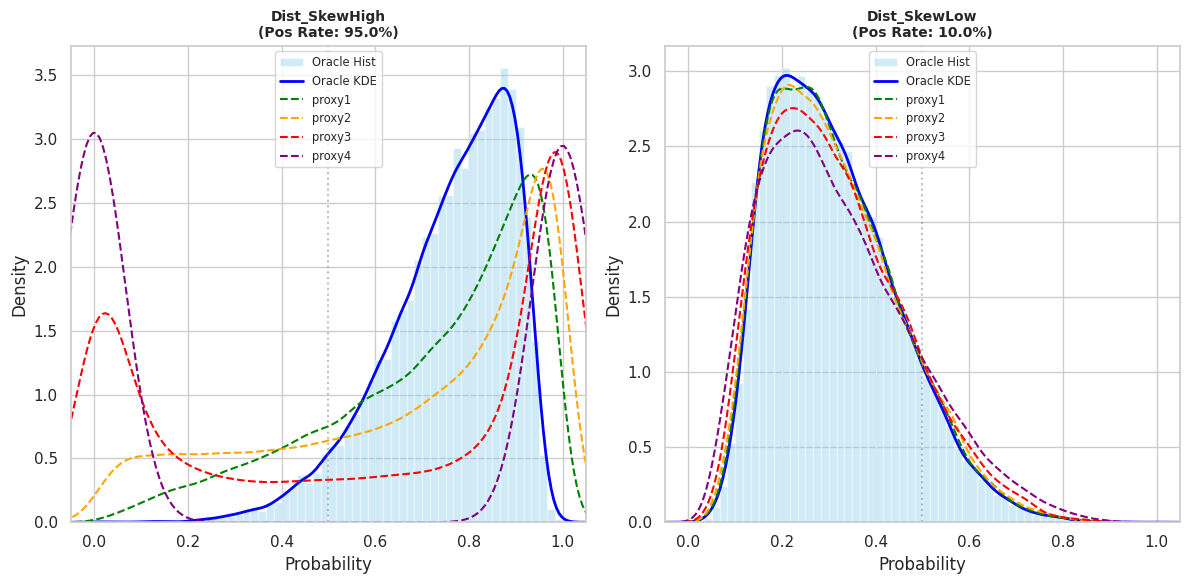

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

def visualize_distributions(
    file_path, 
    target_prefixes=None, 
    figsize=(15, 10), 
    n_cols=3, 
    bins=50, 
    save_path=None
):
    """
    读取 CSV 文件并可视化指定的分布。
    
    参数:
    - file_path: str, post.csv 的文件路径。
    - target_prefixes: list of str, 想要展示的分布前缀列表。
                       例如: ['Dist_Bimodal', 'Dist_SkewLow']。
                       如果为 None，则自动查找所有以 '_oracle_prob' 结尾的列作为前缀。
    - figsize: tuple, 图片整体大小 (宽, 高)。
    - n_cols: int, 一行展示几张图。
    - bins: int, 直方图的柱子数量。
    - save_path: str, 如果不为 None，则将图片保存到该路径。
    """
    
    # 1. 加载数据
    try:
        df = pd.read_csv(file_path)
        print(f"成功加载数据: {file_path}, 共 {len(df)} 行。")
    except FileNotFoundError:
        print(f"错误: 找不到文件 {file_path}")
        return

    # 2. 确定要画哪些分布
    if target_prefixes is None:
        # 自动探测: 寻找所有 XXX_oracle_prob 列，提取 XXX
        target_prefixes = [c.replace('_oracle_prob', '') for c in df.columns if c.endswith('_oracle_prob')]
        print(f"未指定分布，自动检测到以下分布: {target_prefixes}")
    
    # 过滤掉 CSV 中不存在的分布
    valid_prefixes = []
    for p in target_prefixes:
        if f"{p}_oracle_prob" in df.columns:
            valid_prefixes.append(p)
        else:
            print(f"警告: 数据中未找到分布 '{p}' (缺少 {p}_oracle_prob)，跳过。")
    
    if not valid_prefixes:
        print("没有有效的分布可供绘图。")
        return

    # 3. 计算布局
    n_plots = len(valid_prefixes)
    n_rows = math.ceil(n_plots / n_cols)
    
    # 如果只有一行，动态调整高度以免图片被拉伸
    if n_rows == 1 and figsize[1] > 6:
         figsize = (figsize[0], 6)

    # 4. 开始绘图
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # 扁平化 axes 数组方便遍历 (处理只有1个子图的情况)
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 遍历每个分布进行绘制
    for idx, prefix in enumerate(valid_prefixes):
        ax = axes[idx]
        oracle_col = f"{prefix}_oracle_prob"
        
        # 动态查找该分布下所有的 proxy 列 (proxy1, proxy2, ...)
        # 按照列名排序确保颜色顺序一致
        proxy_cols = sorted([c for c in df.columns if c.startswith(prefix) and '_proxy' in c])
        
        # --- A. 画 Oracle (直方图 + KDE) ---
        oracle_data = df[oracle_col].dropna()
        # 直方图
        ax.hist(oracle_data, bins=bins, density=True, color='skyblue', alpha=0.4, label='Oracle Hist')
        # 密度曲线
        sns.kdeplot(oracle_data, ax=ax, color='blue', linewidth=2, label='Oracle KDE')
        
        # --- B. 画 Proxies (仅 KDE) ---
        # 定义一组鲜明的颜色
        colors = ['green', 'orange', 'red', 'purple', 'brown', 'pink']
        
        for i, p_col in enumerate(proxy_cols):
            proxy_data = df[p_col].dropna()
            color = colors[i % len(colors)] # 循环使用颜色
            # 提取 label (例如从 Dist_A_proxy1 提取 proxy1)
            label_name = p_col.split('_')[-1] 
            sns.kdeplot(proxy_data, ax=ax, color=color, linestyle='--', linewidth=1.5, label=label_name)

        # --- C. 图表装饰 ---
        pos_rate = (oracle_data > 0.5).mean()
        ax.set_title(f"{prefix}\n(Pos Rate: {pos_rate:.1%})", fontsize=10, fontweight='bold')
        ax.set_xlim(-0.05, 1.05)
        ax.set_xlabel("Probability")
        ax.set_ylabel("Density")
        
        # 添加 0.5 分界线
        ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
        
        # 图例
        ax.legend(fontsize='x-small', loc='upper center')

    # 5. 隐藏多余的空子图
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    
    # 6. 保存或显示
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {save_path}")
    
    plt.show()

# ==========================================
# 使用示例
# ==========================================

# 假设你的文件路径
csv_path = '/home/wangshuo/resource/datasets/parler_data/dataset_three/csv_data/post.csv'

# 1. 自定义选择展示哪些 (推荐)
# 这里填入你想看的分布的前缀名
# selected_dists = ['Dist_Bimodal_origin','Dist_Bimodal_left','Dist_Bimodal_right']
selected_dists = ['Dist_SkewHigh','Dist_SkewLow']

visualize_distributions(
    file_path=csv_path, 
    target_prefixes=selected_dists, 
    figsize=(18, 10),   # 自定义大小 (宽, 高)
    n_cols=3,          # 一行放3个
    bins=60            # 直方图更细密
)

# 2. 如果你想看文件里所有的分布，不传 target_prefixes 即可
# visualize_distributions(csv_path, n_cols=4, figsize=(20, 15))

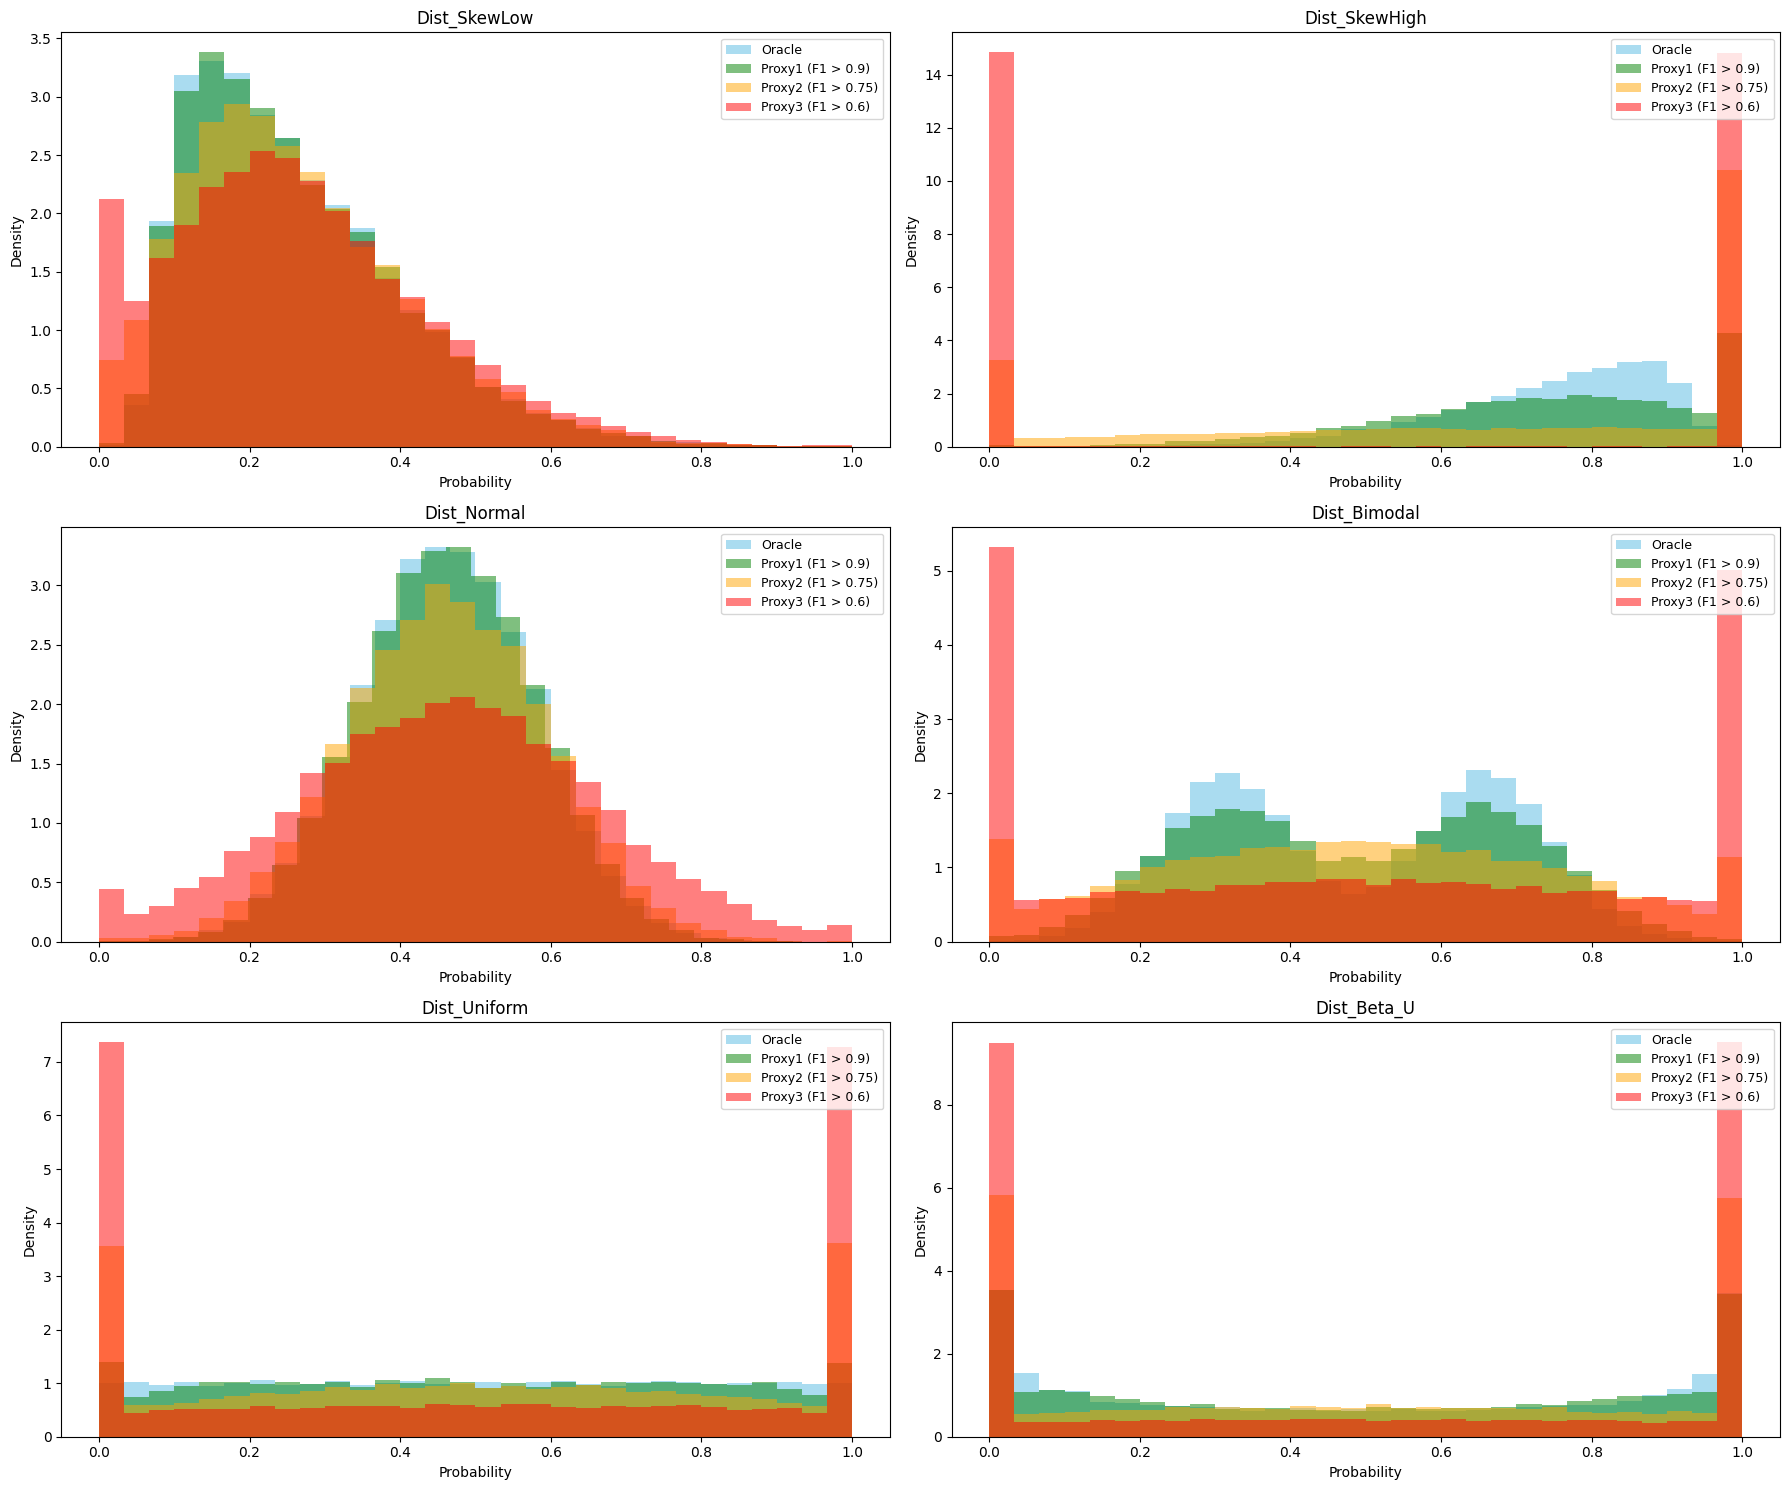

In [3]:
# ==========================================
# 可视化所有分布的 Oracle 和 Proxy
# ==========================================
plt.figure(figsize=(18, 15))

for i, col_name in enumerate(plot_cols):
    plt.subplot(3, 2, i + 1)
    
    # 画 Oracle 分布
    plt.hist(df[col_name], bins=30, color='skyblue', alpha=0.7, label='Oracle', density=True)
    
    # 画 Proxy1 分布
    proxy1_name = col_name.replace('oracle_prob', 'proxy1')
    plt.hist(df[proxy1_name], bins=30, color='green', alpha=0.5, label='Proxy1 (F1 > 0.9)', density=True)
    
    # 画 Proxy2 分布
    proxy2_name = col_name.replace('oracle_prob', 'proxy2')
    plt.hist(df[proxy2_name], bins=30, color='orange', alpha=0.5, label='Proxy2 (F1 > 0.75)', density=True)
    
    # 画 Proxy3 分布
    proxy3_name = col_name.replace('oracle_prob', 'proxy3')
    plt.hist(df[proxy3_name], bins=30, color='red', alpha=0.5, label='Proxy3 (F1 > 0.6)', density=True)
    
    # 设置标题和标签
    plt.title(col_name.replace('_oracle_prob', ''), fontsize=12)
    plt.xlabel('Probability', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

画出所有oracle和proxy的对应图，以及生成的F1分数图

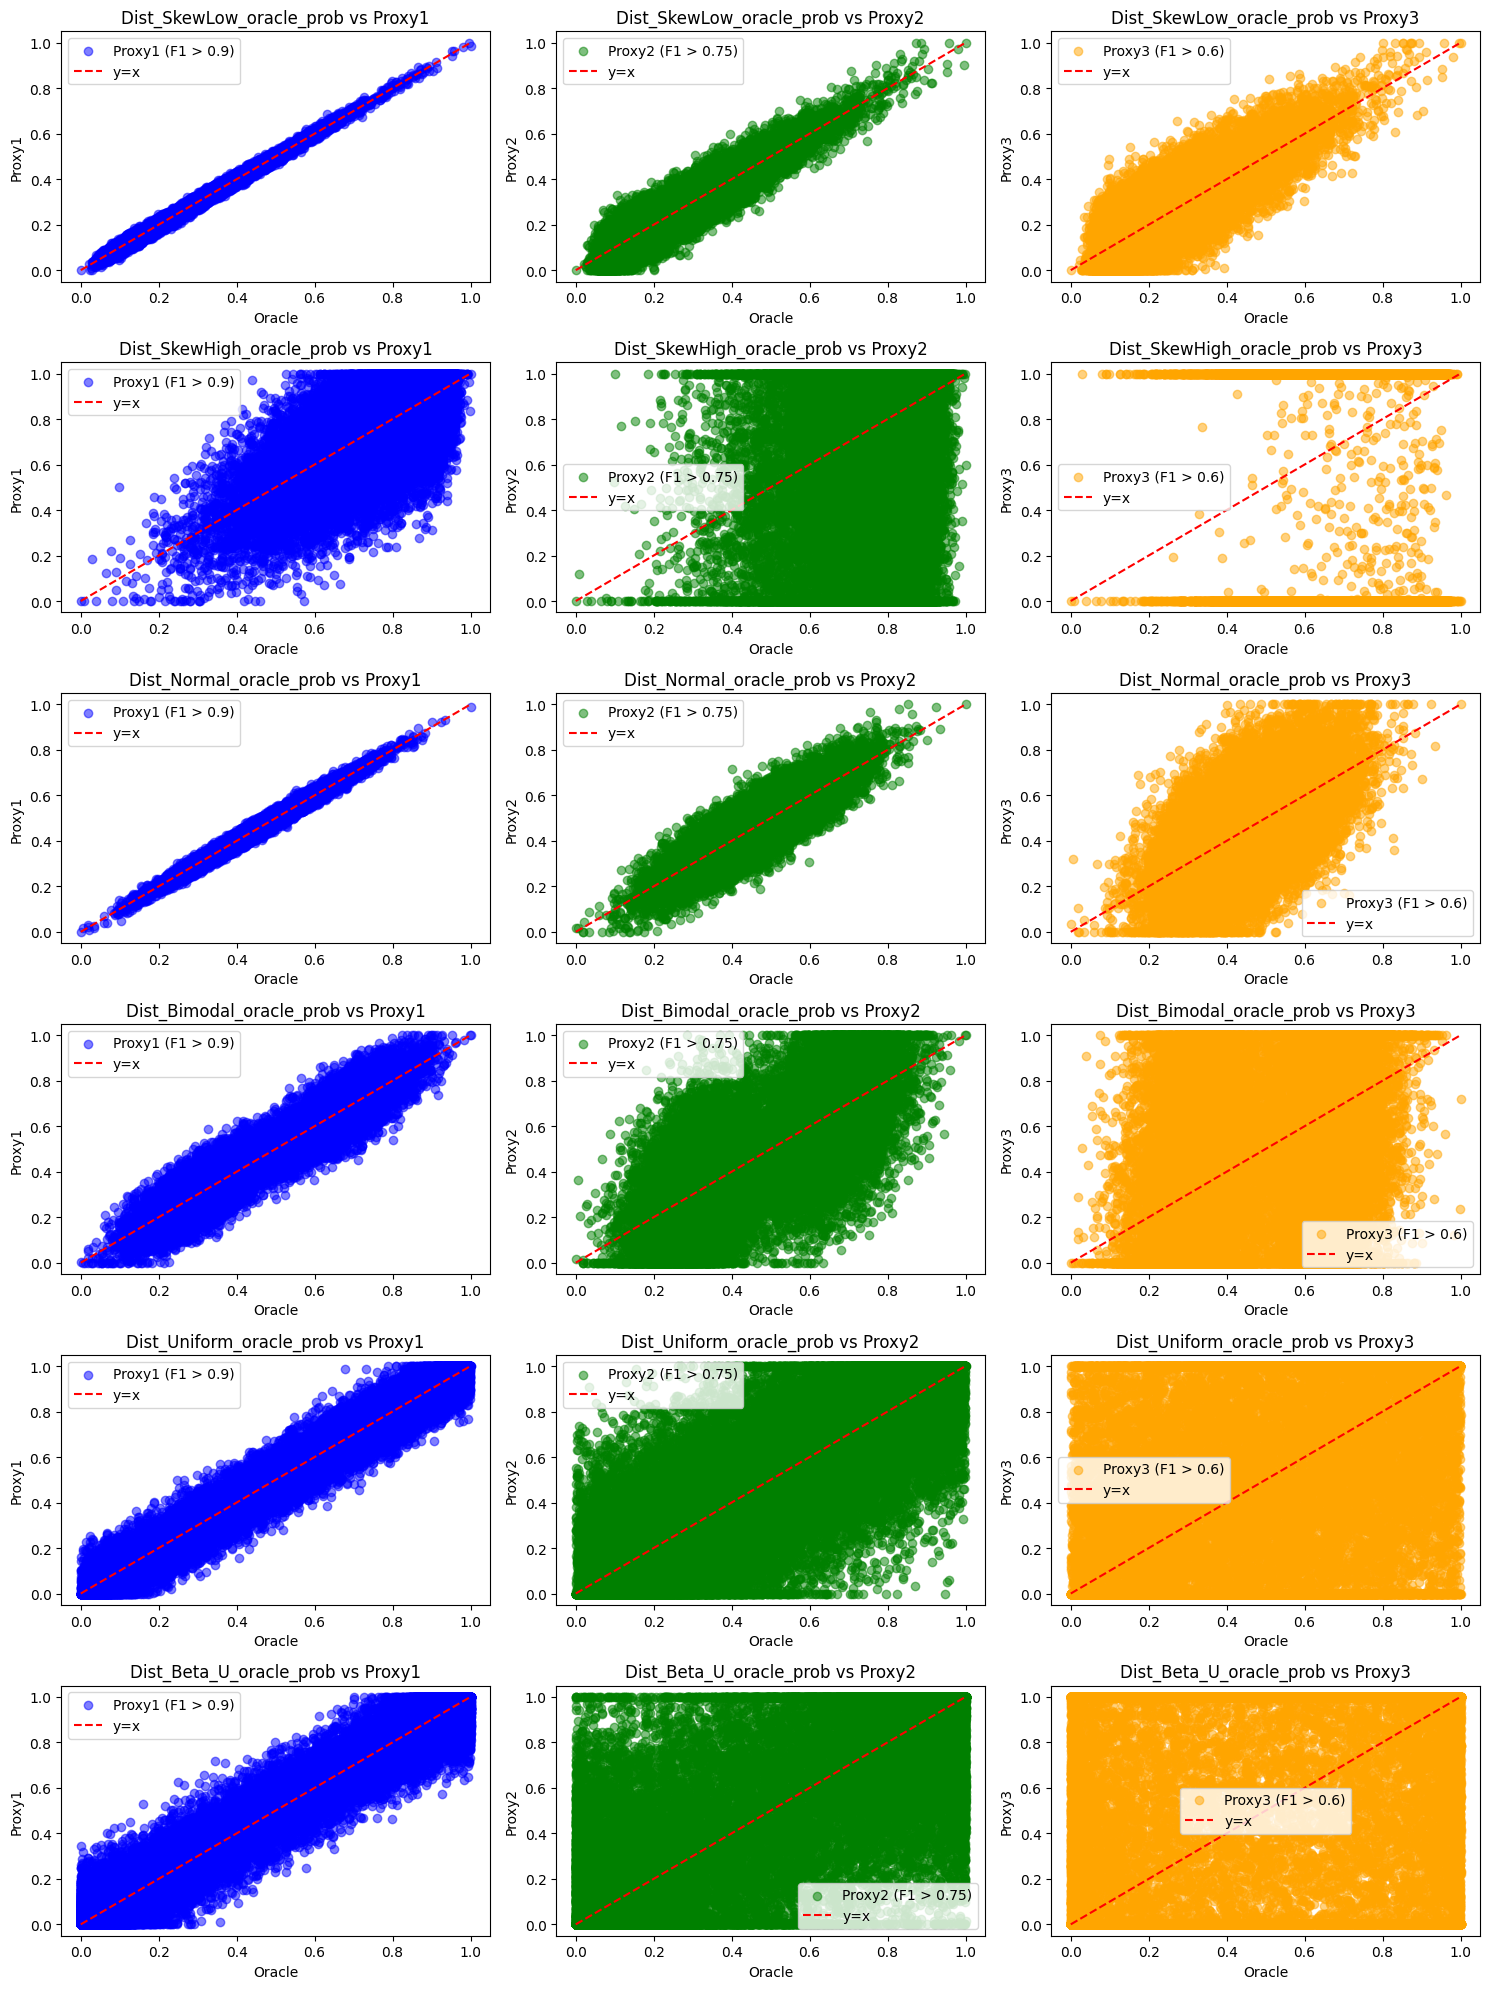

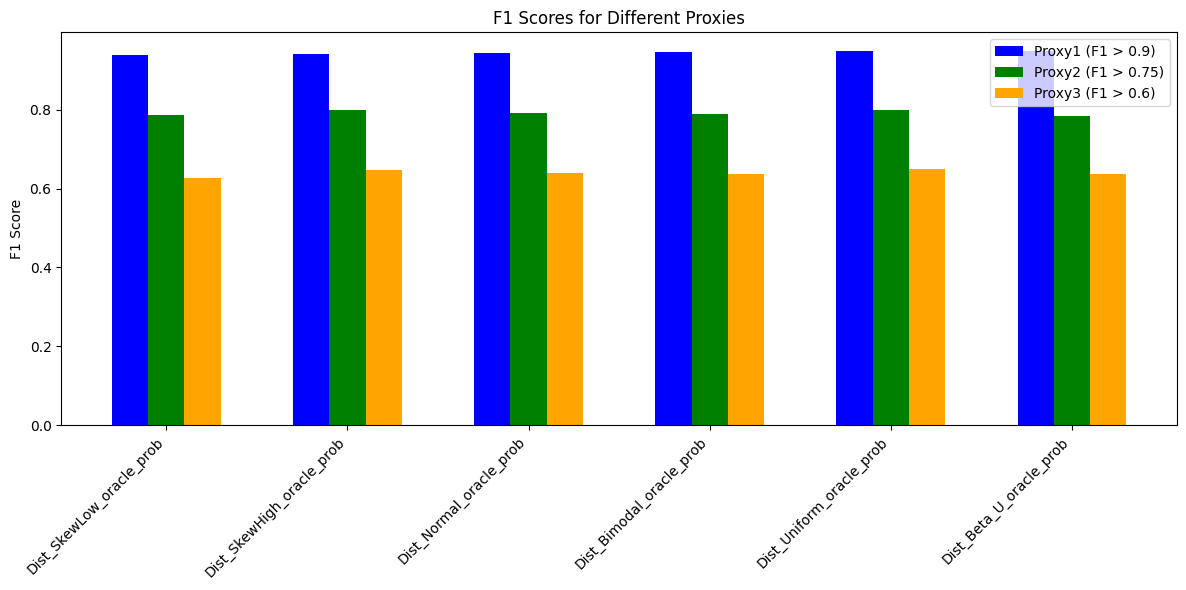

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 绘制 Oracle 和 Proxy 的对应关系图
# ==========================================
plt.figure(figsize=(15, 20))

for i, col_name in enumerate(plot_cols):
    oracle_col = col_name
    proxy1_col = col_name.replace('oracle_prob', 'proxy1')
    proxy2_col = col_name.replace('oracle_prob', 'proxy2')
    proxy3_col = col_name.replace('oracle_prob', 'proxy3')
    
    # 绘制 Proxy1 的散点图
    plt.subplot(len(plot_cols), 3, i * 3 + 1)
    plt.scatter(df[oracle_col], df[proxy1_col], alpha=0.5, color='blue', label='Proxy1 (F1 > 0.9)')
    plt.plot([0, 1], [0, 1], 'r--', label='y=x')
    plt.title(f'{col_name} vs Proxy1')
    plt.xlabel('Oracle')
    plt.ylabel('Proxy1')
    plt.legend()

    # 绘制 Proxy2 的散点图
    plt.subplot(len(plot_cols), 3, i * 3 + 2)
    plt.scatter(df[oracle_col], df[proxy2_col], alpha=0.5, color='green', label='Proxy2 (F1 > 0.75)')
    plt.plot([0, 1], [0, 1], 'r--', label='y=x')
    plt.title(f'{col_name} vs Proxy2')
    plt.xlabel('Oracle')
    plt.ylabel('Proxy2')
    plt.legend()

    # 绘制 Proxy3 的散点图
    plt.subplot(len(plot_cols), 3, i * 3 + 3)
    plt.scatter(df[oracle_col], df[proxy3_col], alpha=0.5, color='orange', label='Proxy3 (F1 > 0.6)')
    plt.plot([0, 1], [0, 1], 'r--', label='y=x')
    plt.title(f'{col_name} vs Proxy3')
    plt.xlabel('Oracle')
    plt.ylabel('Proxy3')
    plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 2. 绘制 F1 分数的柱状图
# ==========================================
f1_scores = []

for col_name in plot_cols:
    oracle_col = col_name
    gt = (df[oracle_col] > 0.5).astype(int)
    proxy1_col = col_name.replace('oracle_prob', 'proxy1')
    proxy2_col = col_name.replace('oracle_prob', 'proxy2')
    proxy3_col = col_name.replace('oracle_prob', 'proxy3')
    
    f1_proxy1 = f1_score(gt, (df[proxy1_col] > 0.5).astype(int))
    f1_proxy2 = f1_score(gt, (df[proxy2_col] > 0.5).astype(int))
    f1_proxy3 = f1_score(gt, (df[proxy3_col] > 0.5).astype(int))
    
    f1_scores.append((col_name, f1_proxy1, f1_proxy2, f1_proxy3))

# 转换为 NumPy 数组以便绘图
f1_scores = np.array(f1_scores, dtype=object)

# 绘制柱状图
x = np.arange(len(f1_scores))  # 分布的数量
width = 0.2  # 柱状图的宽度

plt.figure(figsize=(12, 6))
plt.bar(x - width, f1_scores[:, 1].astype(float), width, label='Proxy1 (F1 > 0.9)', color='blue')
plt.bar(x, f1_scores[:, 2].astype(float), width, label='Proxy2 (F1 > 0.75)', color='green')
plt.bar(x + width, f1_scores[:, 3].astype(float), width, label='Proxy3 (F1 > 0.6)', color='orange')

plt.xticks(x, f1_scores[:, 0], rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.title('F1 Scores for Different Proxies')
plt.legend()
plt.tight_layout()
plt.show()